# 06 _ Model Evaluation and Final Comparison

**Project:** Corporacion Favorita Store Sales Forecasting  
**Project type:** Data Science / MLOps Portfolio Project  
**Notebook:** `notebooks/06_model_evaluation_comparison.ipynb`

---

## 1.Purpose

This notebook compares the forecasting models developed in previous stages and selects the final model recommended for the next MLOps phase.

The evaluation combines technical accuracy, business usefulness, operational granularity, error stability, and deployment readiness.


# 2.Notebook Objective

The objective of this notebook is to make a documented final model recommendation based on consistent validation evidence.

The notebook will:

- Load saved predictions, metrics, configs, and evaluation artifacts.
- Verify that comparisons use compatible validation periods and grains.
- Compare baselines, LightGBM, and Prophet fairly.
- Evaluate global technical and business metrics.
- Analyze errors by date, horizon, store, family, promotion, and holiday/event context.
- Save final leaderboards, decision tables, figures, and recommendation artifacts.


# 3.Scope.

## Scope.

This notebook is a decision notebook and does not train new models.

It includes:

- Final model comparison.
- Granular operational evaluation.
- Daily aggregate evaluation.
- Business-oriented error analysis.
- Final recommendation and next-step artifacts.

It does not include:

- New model training.
- Hyperparameter tuning.
- Rebuilding feature engineering.
- MLflow implementation.
- API or Docker development.


# 4.Imports and Path Setup

This section imports the required libraries, detects the project root, defines expected artifacts, and prepares reusable evaluation helpers.


In [15]:
# Standard library
import json
import warnings
from pathlib import Path
from datetime import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Notebook settings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

SEED = 42
np.random.seed(SEED)

# Project paths
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Data directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
FEATURES_DIR = DATA_DIR / "features"
PREDICTIONS_DIR = DATA_DIR / "predictions"

# Model directories
MODELS_DIR = PROJECT_ROOT / "models"
BASELINES_MODELS_DIR = MODELS_DIR / "baselines"
LIGHTGBM_MODELS_DIR = MODELS_DIR / "lightgbm"
PROPHET_MODELS_DIR = MODELS_DIR / "prophet"

# Report directories
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_TABLES_DIR = REPORTS_DIR / "tables"
REPORTS_FIGURES_DIR = REPORTS_DIR / "figures"

# Compatibility aliases if needed later
TABLES_DIR = REPORTS_TABLES_DIR
FIGURES_DIR = REPORTS_FIGURES_DIR

# Ensure output directories exist
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Features directory: {FEATURES_DIR}")
print(f"Predictions directory: {PREDICTIONS_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Reports tables directory: {REPORTS_TABLES_DIR}")
print(f"Reports figures directory: {REPORTS_FIGURES_DIR}")


Project root: .
Data directory: data
Features directory: data\features
Predictions directory: data\predictions
Models directory: models
Reports tables directory: reports\tables
Reports figures directory: reports\figures


# 5.Evaluation constants and expected artifacts

This section defines the expected model versions, validation grain and artifact paths used in the final comparison.

The notebook expects previous notebooks to have already created predictions, metrics, configurations and segment-level evaluation tables.

The comparison will be performed at two levels:

- granular operational level: `date + store_nbr + family`;
- daily aggregate level: total sales by date.

### Section conclusion

The evaluation will reuse existing outputs only. No model will be trained or modified in this notebook.


In [16]:
# Model versions
BEST_BASELINE_MODEL = None
LIGHTGBM_MODEL_VERSION = "lightgbm_v1"
PROPHET_MODEL_VERSION = "prophet_total_sales_v1"

# Evaluation grain
PREDICTION_GRAIN = ["date", "store_nbr", "family"]
TARGET_COLUMN = "sales"
PREDICTION_COLUMN = "prediction"

# Validation expectations
EXPECTED_FORECAST_HORIZON_DAYS = 16

# Baseline artifacts
BASELINE_VALID_FEATURES_PATH = FEATURES_DIR / "baseline_valid_features.parquet"
BASELINE_VALIDATION_PREDICTIONS_PATH = (
    PREDICTIONS_DIR / "baseline_validation_predictions.parquet"
)
BASELINE_METRICS_PATH = REPORTS_TABLES_DIR / "baseline_metrics.csv"
BASELINE_CONFIG_PATH = BASELINES_MODELS_DIR / "baseline_config.json"
BASELINE_LEADERBOARD_PATH = BASELINES_MODELS_DIR / "baseline_leaderboard.csv"

# LightGBM artifacts
LIGHTGBM_VALIDATION_PREDICTIONS_PATH = (
    PREDICTIONS_DIR / f"{LIGHTGBM_MODEL_VERSION}_validation_predictions.parquet"
)
LIGHTGBM_TEST_PREDICTIONS_PATH = (
    PREDICTIONS_DIR / f"{LIGHTGBM_MODEL_VERSION}_test_predictions.parquet"
)
LIGHTGBM_SUBMISSION_PATH = PREDICTIONS_DIR / f"{LIGHTGBM_MODEL_VERSION}_submission.csv"
LIGHTGBM_METRICS_PATH = REPORTS_TABLES_DIR / f"{LIGHTGBM_MODEL_VERSION}_metrics.csv"
LIGHTGBM_BASELINE_COMPARISON_PATH = (
    REPORTS_TABLES_DIR / f"{LIGHTGBM_MODEL_VERSION}_baseline_comparison.csv"
)
LIGHTGBM_TRAINING_SUMMARY_PATH = (
    REPORTS_TABLES_DIR / f"{LIGHTGBM_MODEL_VERSION}_training_summary.csv"
)
LIGHTGBM_OVERFITTING_SUMMARY_PATH = (
    REPORTS_TABLES_DIR / f"{LIGHTGBM_MODEL_VERSION}_overfitting_summary.csv"
)
LIGHTGBM_FEATURE_GROUP_IMPORTANCE_PATH = (
    REPORTS_TABLES_DIR / f"{LIGHTGBM_MODEL_VERSION}_feature_group_importance.csv"
)
LIGHTGBM_CONFIG_PATH = LIGHTGBM_MODELS_DIR / f"{LIGHTGBM_MODEL_VERSION}_config.json"
LIGHTGBM_FEATURE_LIST_PATH = (
    LIGHTGBM_MODELS_DIR / f"{LIGHTGBM_MODEL_VERSION}_feature_list.json"
)
LIGHTGBM_MODEL_PATH = LIGHTGBM_MODELS_DIR / f"{LIGHTGBM_MODEL_VERSION}_model.txt"

# Prophet artifacts
PROPHET_VALIDATION_PREDICTIONS_PATH = (
    PREDICTIONS_DIR / f"{PROPHET_MODEL_VERSION}_validation_predictions.parquet"
)
PROPHET_METRICS_PATH = REPORTS_TABLES_DIR / f"{PROPHET_MODEL_VERSION}_metrics.csv"
PROPHET_DAILY_COMPARISON_PATH = (
    REPORTS_TABLES_DIR / f"{PROPHET_MODEL_VERSION}_vs_lightgbm_daily_comparison.csv"
)
PROPHET_CONFIG_PATH = PROPHET_MODELS_DIR / f"{PROPHET_MODEL_VERSION}_config.json"
PROPHET_MODEL_PATH = PROPHET_MODELS_DIR / f"{PROPHET_MODEL_VERSION}_model.json"

# Optional enrichment artifacts
HOLIDAYS_DAILY_CLEAN_PATH = INTERIM_DIR / "holidays_daily_clean.parquet"

# Final outputs
FINAL_MODEL_LEADERBOARD_PATH = REPORTS_TABLES_DIR / "final_model_leaderboard.csv"
FINAL_GRANULAR_COMPARISON_PATH = (
    REPORTS_TABLES_DIR / "final_granular_model_comparison.csv"
)
FINAL_DAILY_COMPARISON_PATH = (
    REPORTS_TABLES_DIR / "final_daily_aggregate_model_comparison.csv"
)
FINAL_DECISION_MATRIX_PATH = REPORTS_TABLES_DIR / "final_model_decision_matrix.csv"
FINAL_MODEL_RECOMMENDATION_PATH = REPORTS_TABLES_DIR / "final_model_recommendation.csv"
FINAL_ERROR_BY_DATE_PATH = REPORTS_TABLES_DIR / "final_error_by_date.csv"
FINAL_ERROR_BY_HORIZON_PATH = REPORTS_TABLES_DIR / "final_error_by_horizon_day.csv"
FINAL_ERROR_BY_STORE_PATH = REPORTS_TABLES_DIR / "final_error_by_store.csv"
FINAL_ERROR_BY_FAMILY_PATH = REPORTS_TABLES_DIR / "final_error_by_family.csv"
FINAL_ERROR_BY_PROMOTION_PATH = REPORTS_TABLES_DIR / "final_error_by_promotion.csv"
FINAL_ERROR_BY_HOLIDAY_PATH = REPORTS_TABLES_DIR / "final_error_by_holiday.csv"
MLFLOW_ARTIFACTS_RECOMMENDATION_PATH = (
    REPORTS_TABLES_DIR / "mlflow_artifacts_recommendation.csv"
)
FINAL_NOTEBOOK_CLOSURE_PATH = REPORTS_TABLES_DIR / "final_notebook_closure_criteria.csv"

required_artifacts = {
    "baseline_valid_features": BASELINE_VALID_FEATURES_PATH,
    "baseline_validation_predictions": BASELINE_VALIDATION_PREDICTIONS_PATH,
    "baseline_metrics": BASELINE_METRICS_PATH,
    "baseline_config": BASELINE_CONFIG_PATH,
    "lightgbm_validation_predictions": LIGHTGBM_VALIDATION_PREDICTIONS_PATH,
    "lightgbm_metrics": LIGHTGBM_METRICS_PATH,
    "lightgbm_config": LIGHTGBM_CONFIG_PATH,
    "prophet_validation_predictions": PROPHET_VALIDATION_PREDICTIONS_PATH,
    "prophet_metrics": PROPHET_METRICS_PATH,
    "prophet_config": PROPHET_CONFIG_PATH,
}

optional_artifacts = {
    "baseline_leaderboard": BASELINE_LEADERBOARD_PATH,
    "lightgbm_test_predictions": LIGHTGBM_TEST_PREDICTIONS_PATH,
    "lightgbm_submission": LIGHTGBM_SUBMISSION_PATH,
    "lightgbm_baseline_comparison": LIGHTGBM_BASELINE_COMPARISON_PATH,
    "lightgbm_training_summary": LIGHTGBM_TRAINING_SUMMARY_PATH,
    "lightgbm_overfitting_summary": LIGHTGBM_OVERFITTING_SUMMARY_PATH,
    "lightgbm_feature_group_importance": LIGHTGBM_FEATURE_GROUP_IMPORTANCE_PATH,
    "lightgbm_feature_list": LIGHTGBM_FEATURE_LIST_PATH,
    "lightgbm_model": LIGHTGBM_MODEL_PATH,
    "prophet_daily_comparison": PROPHET_DAILY_COMPARISON_PATH,
    "prophet_model": PROPHET_MODEL_PATH,
    "holidays_daily_clean": HOLIDAYS_DAILY_CLEAN_PATH,
}


def file_size_mb(path):
    """Return file size in MB if the file exists."""
    path = Path(path)

    if not path.exists():
        return np.nan

    return round(path.stat().st_size / (1024**2), 4)


artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "required": True,
            "path": artifact_path,
            "relative_path": (
                artifact_path.relative_to(PROJECT_ROOT)
                if artifact_path.exists()
                else str(artifact_path)
            ),
            "exists": artifact_path.exists(),
            "file_size_mb": file_size_mb(artifact_path),
        }
        for artifact_name, artifact_path in required_artifacts.items()
    ]
    + [
        {
            "artifact": artifact_name,
            "required": False,
            "path": artifact_path,
            "relative_path": (
                artifact_path.relative_to(PROJECT_ROOT)
                if artifact_path.exists()
                else str(artifact_path)
            ),
            "exists": artifact_path.exists(),
            "file_size_mb": file_size_mb(artifact_path),
        }
        for artifact_name, artifact_path in optional_artifacts.items()
    ]
)

display(artifact_inventory)

missing_required_artifacts = artifact_inventory.query(
    "required == True and exists == False"
)

if not missing_required_artifacts.empty:
    raise FileNotFoundError(
        "Missing required artifacts:\n"
        + "\n".join(
            [
                f"- {row.artifact}: {row.path}"
                for row in missing_required_artifacts.itertuples(index=False)
            ]
        )
    )

print("Required artifacts are available.")


,artifact,required,path,relative_path,exists,file_size_mb
0,baseline_valid_features,True,....,data\features\baseline_valid_features.parquet,True,0.8034
1,baseline_validation_predictions,True,....,data\predictions\baseline_validation_predictio...,True,0.3274
2,baseline_metrics,True,....,reports\tables\baseline_metrics.csv,True,0.0011
3,baseline_config,True,....,models\baselines\baseline_config.json,True,0.0030
4,lightgbm_validation_predictions,True,....,data\predictions\lightgbm_v1_validation_predic...,True,1.5780
5,lightgbm_metrics,True,....,reports\tables\lightgbm_v1_metrics.csv,True,0.0002
6,lightgbm_config,True,....,models\lightgbm\lightgbm_v1_config.json,True,0.0050
7,prophet_validation_predictions,True,....,data\predictions\prophet_total_sales_v1_valida...,True,0.0082
8,prophet_metrics,True,....,reports\tables\prophet_total_sales_v1_metrics.csv,True,0.0002
9,prophet_config,True,....,models\prophet\prophet_total_sales_v1_config.json,True,0.0035


Required artifacts are available.


# 6.Helper functions

This section defines reusable functions for reading artifacts, computing metrics, validating grains, enriching predictions and saving final outputs.

The metric definitions are consistent with previous notebooks:

- RMSLE as the main Kaggle-style metric;
- MAE as absolute error magnitude;
- WAPE as business-level relative error;
- bias and total bias percentage as operational planning risk metrics.

### Section conclusion

The notebook uses the same evaluation logic across models to avoid inconsistent metric calculations.


In [ ]:
def dataframe_memory_mb(df):
    """Return DataFrame memory usage in MB."""
    return round(df.memory_usage(deep=True).sum() / (1024**2), 4)


def read_csv(path, dataset_name):
    """Read a CSV file with a compact log."""
    path = Path(path)
    df = pd.read_csv(path)
    print(f"Loaded {dataset_name}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
    return df


def read_parquet(path, dataset_name):
    """Read a parquet file with a compact log."""
    path = Path(path)
    df = pd.read_parquet(path)
    print(
        f"Loaded {dataset_name}: "
        f"{df.shape[0]:,} rows, {df.shape[1]:,} columns, "
        f"{dataframe_memory_mb(df):,.2f} MB"
    )
    return df


def read_json(path, artifact_name):
    """Read a JSON file."""
    path = Path(path)

    with open(path, "r", encoding="utf-8") as file:
        data = json.load(file)

    print(f"Loaded {artifact_name}: {path.name}")
    return data


def read_optional_csv(path, dataset_name):
    """Read a CSV file only if it exists."""
    path = Path(path)

    if not path.exists():
        print(f"Optional artifact not found: {dataset_name}")
        return None

    return read_csv(path, dataset_name)


def read_optional_json(path, artifact_name):
    """Read a JSON file only if it exists."""
    path = Path(path)

    if not path.exists():
        print(f"Optional artifact not found: {artifact_name}")
        return None

    return read_json(path, artifact_name)


def ensure_datetime(df, columns=("date", "ds")):
    """Convert date-like columns to datetime if present."""
    df = df.copy()

    for column in columns:
        if column in df.columns:
            df[column] = pd.to_datetime(df[column])

    return df


def require_columns(df, required_columns, dataset_name):
    """Validate that a DataFrame contains the required columns."""
    missing_columns = [
        column for column in required_columns if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing required columns: {missing_columns}"
        )


def clip_forecast_predictions(predictions):
    """Clip forecast predictions to avoid negative sales."""
    return np.clip(np.asarray(predictions, dtype=float), 0, None)


def rmsle_score(y_true, y_pred):
    """Compute Root Mean Squared Logarithmic Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_forecast_predictions(y_pred)

    y_true = np.maximum(y_true, 0)

    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))


def mae_score(y_true, y_pred):
    """Compute Mean Absolute Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_forecast_predictions(y_pred)

    return np.mean(np.abs(y_true - y_pred))


def wape_score(y_true, y_pred):
    """Compute Weighted Absolute Percentage Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_forecast_predictions(y_pred)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator


def bias_score(y_true, y_pred):
    """Compute average forecast bias."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_forecast_predictions(y_pred)

    return np.mean(y_pred - y_true)


def total_bias_pct_score(y_true, y_pred):
    """Compute total forecast bias as percentage of total actual sales."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_forecast_predictions(y_pred)

    denominator = np.sum(y_true)

    if denominator == 0:
        return np.nan

    return (np.sum(y_pred) - np.sum(y_true)) / denominator


def evaluate_forecast(y_true, y_pred, model_name, granularity):
    """Return the main forecasting metrics as a one-row DataFrame."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_forecast_predictions(y_pred)

    return pd.DataFrame(
        [
            {
                "model": model_name,
                "granularity": granularity,
                "rows": len(y_true),
                "rmsle": rmsle_score(y_true, y_pred),
                "mae": mae_score(y_true, y_pred),
                "wape": wape_score(y_true, y_pred),
                "bias": bias_score(y_true, y_pred),
                "total_bias_pct": total_bias_pct_score(y_true, y_pred),
                "actual_total_sales": np.sum(y_true),
                "predicted_total_sales": np.sum(y_pred),
            }
        ]
    )


def add_error_columns(df, actual_col, prediction_col="prediction"):
    """Add residual and error columns to a prediction DataFrame."""
    df = df.copy()

    df[prediction_col] = clip_forecast_predictions(df[prediction_col])
    df["residual"] = df[prediction_col] - df[actual_col]
    df["absolute_error"] = df["residual"].abs()
    df["squared_log_error"] = (
        np.log1p(df[prediction_col].clip(lower=0))
        - np.log1p(df[actual_col].clip(lower=0))
    ) ** 2

    df["absolute_percentage_error_safe"] = np.where(
        df[actual_col] > 0,
        df["absolute_error"] / df[actual_col],
        np.nan,
    )

    return df


def build_horizon_day(df, date_col="date"):
    """Add horizon day based on sorted validation dates."""
    df = df.copy()
    validation_dates = sorted(df[date_col].dropna().unique())
    date_to_horizon_day = {
        date: horizon_day for horizon_day, date in enumerate(validation_dates, start=1)
    }

    df["horizon_day"] = df[date_col].map(date_to_horizon_day).astype("int16")

    return df


def evaluate_forecast_group(group, actual_col, prediction_col):
    """Compute forecasting metrics for a grouped prediction table."""
    y_true = group[actual_col].to_numpy()
    y_pred = group[prediction_col].to_numpy()

    return pd.Series(
        {
            "rows": len(group),
            "actual_total_sales": np.sum(y_true),
            "predicted_total_sales": np.sum(clip_forecast_predictions(y_pred)),
            "rmsle": rmsle_score(y_true, y_pred),
            "mae": mae_score(y_true, y_pred),
            "wape": wape_score(y_true, y_pred),
            "bias": bias_score(y_true, y_pred),
            "total_bias_pct": total_bias_pct_score(y_true, y_pred),
            "total_absolute_error": np.sum(
                np.abs(y_true - clip_forecast_predictions(y_pred))
            ),
        }
    )


def metrics_by_segment(
    df, group_columns, actual_col="sales", prediction_col="prediction"
):
    """Aggregate forecast metrics by one or more segment columns."""
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    segment_metrics = (
        df.groupby(group_columns, observed=True)
        .apply(
            lambda group: evaluate_forecast_group(
                group=group,
                actual_col=actual_col,
                prediction_col=prediction_col,
            )
        )
        .reset_index()
    )

    total_absolute_error = segment_metrics["total_absolute_error"].sum()

    if total_absolute_error > 0:
        segment_metrics["error_contribution_pct"] = (
            segment_metrics["total_absolute_error"] / total_absolute_error
        )
    else:
        segment_metrics["error_contribution_pct"] = np.nan

    return segment_metrics


def save_dataframe(df, path):
    """Save DataFrame as CSV."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def plot_barh(df, label_col, value_col, title, output_path, n_rows=15):
    """Create and save a horizontal bar chart."""
    plot_df = df.copy().head(n_rows).sort_values(value_col, ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df[label_col].astype(str), plot_df[value_col])
    plt.title(title)
    plt.xlabel(value_col)
    plt.tight_layout()
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()


def plot_line(df, x_col, y_cols, title, output_path):
    """Create and save a line chart."""
    plt.figure(figsize=(12, 5))

    for y_col in y_cols:
        plt.plot(df[x_col], df[y_col], marker="o", label=y_col)

    plt.title(title)
    plt.xlabel(x_col)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()


# 7.Load model artifacts

This section loads the existing predictions, metrics and configuration files from previous notebooks.

Loaded artifacts include:

- baseline validation predictions and metrics;
- LightGBM validation predictions and metrics;
- Prophet validation predictions and metrics;
- validation features used for segment enrichment;
- optional model comparison and training diagnostic tables.

### Section conclusion

The notebook starts from saved outputs, preserving the separation between model training and model evaluation.


In [ ]:
baseline_valid_features = ensure_datetime(
    read_parquet(BASELINE_VALID_FEATURES_PATH, "baseline_valid_features")
)

baseline_validation_predictions = ensure_datetime(
    read_parquet(
        BASELINE_VALIDATION_PREDICTIONS_PATH, "baseline_validation_predictions"
    )
)

baseline_metrics = read_csv(BASELINE_METRICS_PATH, "baseline_metrics")
baseline_config = read_json(BASELINE_CONFIG_PATH, "baseline_config")

lightgbm_validation_predictions = ensure_datetime(
    read_parquet(
        LIGHTGBM_VALIDATION_PREDICTIONS_PATH, "lightgbm_validation_predictions"
    )
)

lightgbm_metrics = read_csv(LIGHTGBM_METRICS_PATH, "lightgbm_metrics")
lightgbm_config = read_json(LIGHTGBM_CONFIG_PATH, "lightgbm_config")

prophet_validation_predictions = ensure_datetime(
    read_parquet(PROPHET_VALIDATION_PREDICTIONS_PATH, "prophet_validation_predictions")
)

prophet_metrics = read_csv(PROPHET_METRICS_PATH, "prophet_metrics")
prophet_config = read_json(PROPHET_CONFIG_PATH, "prophet_config")

lightgbm_baseline_comparison = read_optional_csv(
    LIGHTGBM_BASELINE_COMPARISON_PATH,
    "lightgbm_baseline_comparison",
)

lightgbm_training_summary = read_optional_csv(
    LIGHTGBM_TRAINING_SUMMARY_PATH,
    "lightgbm_training_summary",
)

lightgbm_overfitting_summary = read_optional_csv(
    LIGHTGBM_OVERFITTING_SUMMARY_PATH,
    "lightgbm_overfitting_summary",
)

lightgbm_feature_group_importance = read_optional_csv(
    LIGHTGBM_FEATURE_GROUP_IMPORTANCE_PATH,
    "lightgbm_feature_group_importance",
)

prophet_daily_comparison_existing = read_optional_csv(
    PROPHET_DAILY_COMPARISON_PATH,
    "prophet_daily_comparison_existing",
)

if HOLIDAYS_DAILY_CLEAN_PATH.exists():
    holidays_daily_clean = ensure_datetime(
        read_parquet(HOLIDAYS_DAILY_CLEAN_PATH, "holidays_daily_clean")
    )
else:
    holidays_daily_clean = None

loaded_datasets_summary = pd.DataFrame(
    [
        {
            "dataset": "baseline_valid_features",
            "rows": len(baseline_valid_features),
            "columns": baseline_valid_features.shape[1],
            "memory_mb": dataframe_memory_mb(baseline_valid_features),
        },
        {
            "dataset": "baseline_validation_predictions",
            "rows": len(baseline_validation_predictions),
            "columns": baseline_validation_predictions.shape[1],
            "memory_mb": dataframe_memory_mb(baseline_validation_predictions),
        },
        {
            "dataset": "lightgbm_validation_predictions",
            "rows": len(lightgbm_validation_predictions),
            "columns": lightgbm_validation_predictions.shape[1],
            "memory_mb": dataframe_memory_mb(lightgbm_validation_predictions),
        },
        {
            "dataset": "prophet_validation_predictions",
            "rows": len(prophet_validation_predictions),
            "columns": prophet_validation_predictions.shape[1],
            "memory_mb": dataframe_memory_mb(prophet_validation_predictions),
        },
    ]
)

display(loaded_datasets_summary)


Loaded baseline_valid_features: 28,512 rows, 44 columns, 7.14 MB
Loaded baseline_validation_predictions: 28,512 rows, 12 columns, 2.20 MB
Loaded baseline_metrics: 5 rows, 12 columns
Loaded baseline_config: baseline_config.json
Loaded lightgbm_validation_predictions: 28,512 rows, 14 columns, 3.42 MB
Loaded lightgbm_metrics: 1 rows, 9 columns
Loaded lightgbm_config: lightgbm_v1_config.json
Loaded prophet_validation_predictions: 16 rows, 12 columns, 0.00 MB
Loaded prophet_metrics: 1 rows, 9 columns
Loaded prophet_config: prophet_total_sales_v1_config.json
Loaded lightgbm_baseline_comparison: 6 rows, 13 columns
Loaded lightgbm_training_summary: 1 rows, 9 columns
Loaded lightgbm_overfitting_summary: 1 rows, 12 columns
Loaded lightgbm_feature_group_importance: 7 rows, 6 columns
Loaded prophet_daily_comparison_existing: 16 rows, 14 columns
Loaded holidays_daily_clean: 1,704 rows, 17 columns, 0.19 MB


,dataset,rows,columns,memory_mb
0,baseline_valid_features,28512,44,7.1383
1,baseline_validation_predictions,28512,12,2.1960
2,lightgbm_validation_predictions,28512,14,3.4183
3,prophet_validation_predictions,16,12,0.0019


# 8.Evaluation integrity checks

This section verifies that the model comparison is valid before calculating final conclusions.

The checks focus on:

- expected prediction columns;
- validation period alignment;
- prediction grain uniqueness;
- validation horizon length;
- Prophet aggregate granularity;
- leakage-related assumptions from previous notebooks.

### Section conclusion

A model comparison should only be trusted after verifying that the predictions refer to the same validation window and compatible evaluation levels.


In [19]:
# Required columns
require_columns(
    baseline_valid_features,
    PREDICTION_GRAIN + [TARGET_COLUMN],
    "baseline_valid_features",
)

require_columns(
    baseline_validation_predictions,
    PREDICTION_GRAIN + [TARGET_COLUMN],
    "baseline_validation_predictions",
)

require_columns(
    lightgbm_validation_predictions,
    PREDICTION_GRAIN + [TARGET_COLUMN, PREDICTION_COLUMN],
    "lightgbm_validation_predictions",
)

require_columns(
    prophet_validation_predictions,
    ["ds", "actual", PREDICTION_COLUMN],
    "prophet_validation_predictions",
)

# Best baseline selection
if BEST_BASELINE_MODEL is None:
    BEST_BASELINE_MODEL = baseline_config.get("best_baseline")

if BEST_BASELINE_MODEL is None:
    baseline_model_col = (
        "baseline" if "baseline" in baseline_metrics.columns else "model"
    )
    BEST_BASELINE_MODEL = baseline_metrics.sort_values(["rmsle", "wape", "mae"]).iloc[
        0
    ][baseline_model_col]

if BEST_BASELINE_MODEL not in baseline_validation_predictions.columns:
    raise ValueError(
        f"Best baseline column '{BEST_BASELINE_MODEL}' "
        "was not found in baseline_validation_predictions."
    )

print(f"Best baseline selected for final comparison: {BEST_BASELINE_MODEL}")

# Build baseline best prediction table
baseline_best_predictions = baseline_validation_predictions[
    [
        column
        for column in (
            PREDICTION_GRAIN
            + [
                TARGET_COLUMN,
                "onpromotion",
                "day_of_week",
                "horizon_day",
                BEST_BASELINE_MODEL,
            ]
        )
        if column in baseline_validation_predictions.columns
    ]
].copy()

baseline_best_predictions = baseline_best_predictions.rename(
    columns={BEST_BASELINE_MODEL: PREDICTION_COLUMN}
)

baseline_best_predictions["model"] = BEST_BASELINE_MODEL

# Standardize prediction tables
baseline_best_predictions = add_error_columns(
    baseline_best_predictions,
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

lightgbm_validation_predictions = add_error_columns(
    lightgbm_validation_predictions,
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

if "horizon_day" not in baseline_best_predictions.columns:
    baseline_best_predictions = build_horizon_day(baseline_best_predictions, "date")

if "horizon_day" not in lightgbm_validation_predictions.columns:
    lightgbm_validation_predictions = build_horizon_day(
        lightgbm_validation_predictions, "date"
    )

# Enrich granular predictions with validation features
enrichment_candidates = [
    "city",
    "state",
    "store_type",
    "cluster",
    "calendar_event_count",
    "transferred_event_count",
    "non_transferred_event_count",
    "is_calendar_event",
    "has_non_transferred_event",
    "has_transferred_event",
    "dcoilwtico",
    "dcoilwtico_was_imputed",
]

available_enrichment_columns = [
    column
    for column in enrichment_candidates
    if column in baseline_valid_features.columns
]

enrichment_table = baseline_valid_features[
    PREDICTION_GRAIN + available_enrichment_columns
].drop_duplicates(PREDICTION_GRAIN)

baseline_best_predictions = baseline_best_predictions.merge(
    enrichment_table,
    on=PREDICTION_GRAIN,
    how="left",
)

lightgbm_validation_predictions = lightgbm_validation_predictions.merge(
    enrichment_table,
    on=PREDICTION_GRAIN,
    how="left",
)

# Promotion segment
for df in [baseline_best_predictions, lightgbm_validation_predictions]:
    if "onpromotion" in df.columns:
        df["promotion_status"] = np.where(
            df["onpromotion"] > 0,
            "with_promotion",
            "without_promotion",
        )
    else:
        df["promotion_status"] = "unknown"

# Holiday segment
for df in [baseline_best_predictions, lightgbm_validation_predictions]:
    if "has_non_transferred_event" in df.columns:
        df["holiday_status"] = np.where(
            df["has_non_transferred_event"] == 1,
            "holiday_or_event",
            "normal_day",
        )
    elif "is_calendar_event" in df.columns:
        df["holiday_status"] = np.where(
            df["is_calendar_event"] == 1,
            "holiday_or_event",
            "normal_day",
        )
    elif "calendar_event_count" in df.columns:
        df["holiday_status"] = np.where(
            df["calendar_event_count"] > 0,
            "holiday_or_event",
            "normal_day",
        )
    else:
        df["holiday_status"] = "unknown"

# Integrity checks
baseline_validation_dates = sorted(baseline_best_predictions["date"].unique())
lightgbm_validation_dates = sorted(lightgbm_validation_predictions["date"].unique())
prophet_validation_dates = sorted(prophet_validation_predictions["ds"].unique())

baseline_grain_duplicates = baseline_best_predictions.duplicated(PREDICTION_GRAIN).sum()
lightgbm_grain_duplicates = lightgbm_validation_predictions.duplicated(
    PREDICTION_GRAIN
).sum()
prophet_date_duplicates = prophet_validation_predictions.duplicated(["ds"]).sum()

integrity_checks = pd.DataFrame(
    [
        {
            "check": "baseline_prediction_grain_unique",
            "status": "passed" if baseline_grain_duplicates == 0 else "failed",
            "details": baseline_grain_duplicates,
        },
        {
            "check": "lightgbm_prediction_grain_unique",
            "status": "passed" if lightgbm_grain_duplicates == 0 else "failed",
            "details": lightgbm_grain_duplicates,
        },
        {
            "check": "prophet_daily_grain_unique",
            "status": "passed" if prophet_date_duplicates == 0 else "failed",
            "details": prophet_date_duplicates,
        },
        {
            "check": "baseline_lightgbm_same_dates",
            "status": (
                "passed"
                if baseline_validation_dates == lightgbm_validation_dates
                else "failed"
            ),
            "details": f"{min(lightgbm_validation_dates)} to {max(lightgbm_validation_dates)}",
        },
        {
            "check": "lightgbm_prophet_same_dates_at_daily_level",
            "status": (
                "passed"
                if lightgbm_validation_dates == prophet_validation_dates
                else "failed"
            ),
            "details": f"{min(prophet_validation_dates)} to {max(prophet_validation_dates)}",
        },
        {
            "check": "expected_forecast_horizon_days",
            "status": (
                "passed"
                if len(lightgbm_validation_dates) == EXPECTED_FORECAST_HORIZON_DAYS
                else "review"
            ),
            "details": len(lightgbm_validation_dates),
        },
        {
            "check": "prophet_not_granular",
            "status": "passed",
            "details": "Prophet is evaluated only at daily aggregate level.",
        },
        {
            "check": "comparison_leakage_assumption",
            "status": "passed",
            "details": "This notebook only evaluates saved validation predictions and does not recompute future-looking features.",
        },
    ]
)

display(integrity_checks)

failed_checks = integrity_checks.query("status == 'failed'")

if not failed_checks.empty:
    raise ValueError(
        "Some integrity checks failed. Review before continuing:\n"
        + "\n".join(
            [
                f"- {row.check}: {row.details}"
                for row in failed_checks.itertuples(index=False)
            ]
        )
    )

print("Evaluation integrity checks passed.")


Best baseline selected for final comparison: baseline_rolling_mean_28_origin


,check,status,details
0,baseline_prediction_grain_unique,passed,0
1,lightgbm_prediction_grain_unique,passed,0
2,prophet_daily_grain_unique,passed,0
3,baseline_lightgbm_same_dates,passed,2017-07-31 00:00:00 to 2017-08-15 00:00:00
4,lightgbm_prophet_same_dates_at_daily_level,passed,2017-07-31 00:00:00 to 2017-08-15 00:00:00
5,expected_forecast_horizon_days,passed,16
6,prophet_not_granular,passed,Prophet is evaluated only at daily aggregate l...
7,comparison_leakage_assumption,passed,This notebook only evaluates saved validation ...


Evaluation integrity checks passed.


### Section conclusion

The comparison is valid for two levels:

- Baseline and LightGBM can be compared at `date + store_nbr + family` level.
- Prophet can only be compared against LightGBM after aggregating LightGBM predictions by date.

This prevents an unfair comparison between models with different prediction granularity.


# 9.Global model leaderboard

This section creates a high-level leaderboard including:

- the best baseline at granular level;
- LightGBM at granular level;
- Prophet at daily aggregate level;
- LightGBM aggregated to daily total sales level.

The leaderboard is useful as an executive summary, but the final decision must still respect granularity differences.

### Section conclusion

The leaderboard summarizes model performance, but the final decision will be made using operational grain, business metrics and deployment readiness.


In [ ]:
baseline_global_metrics = evaluate_forecast(
    y_true=baseline_best_predictions[TARGET_COLUMN],
    y_pred=baseline_best_predictions[PREDICTION_COLUMN],
    model_name=BEST_BASELINE_MODEL,
    granularity="date_store_family",
)

lightgbm_global_metrics = evaluate_forecast(
    y_true=lightgbm_validation_predictions[TARGET_COLUMN],
    y_pred=lightgbm_validation_predictions[PREDICTION_COLUMN],
    model_name=LIGHTGBM_MODEL_VERSION,
    granularity="date_store_family",
)

lightgbm_daily_predictions = (
    lightgbm_validation_predictions.groupby("date", as_index=False)
    .agg(
        actual=(TARGET_COLUMN, "sum"),
        prediction=(PREDICTION_COLUMN, "sum"),
    )
    .rename(columns={"date": "ds"})
    .sort_values("ds")
    .reset_index(drop=True)
)

lightgbm_daily_predictions["model"] = f"{LIGHTGBM_MODEL_VERSION}_daily_aggregate"
lightgbm_daily_predictions = add_error_columns(
    lightgbm_daily_predictions,
    actual_col="actual",
    prediction_col="prediction",
)

prophet_daily_predictions = prophet_validation_predictions[
    [
        column
        for column in [
            "ds",
            "actual",
            "prediction",
            "yhat",
            "trend",
            "weekly",
            "yearly",
            "holidays",
        ]
        if column in prophet_validation_predictions.columns
    ]
].copy()

prophet_daily_predictions["model"] = PROPHET_MODEL_VERSION

if (
    "prediction" not in prophet_daily_predictions.columns
    and "yhat" in prophet_daily_predictions.columns
):
    prophet_daily_predictions["prediction"] = prophet_daily_predictions["yhat"]

prophet_daily_predictions = add_error_columns(
    prophet_daily_predictions,
    actual_col="actual",
    prediction_col="prediction",
)

lightgbm_daily_metrics = evaluate_forecast(
    y_true=lightgbm_daily_predictions["actual"],
    y_pred=lightgbm_daily_predictions["prediction"],
    model_name=f"{LIGHTGBM_MODEL_VERSION}_daily_aggregate",
    granularity="daily_total_sales",
)

prophet_daily_metrics = evaluate_forecast(
    y_true=prophet_daily_predictions["actual"],
    y_pred=prophet_daily_predictions["prediction"],
    model_name=PROPHET_MODEL_VERSION,
    granularity="daily_total_sales",
)

final_model_leaderboard = pd.concat(
    [
        baseline_global_metrics,
        lightgbm_global_metrics,
        lightgbm_daily_metrics,
        prophet_daily_metrics,
    ],
    ignore_index=True,
)

final_model_leaderboard["abs_total_bias_pct"] = final_model_leaderboard[
    "total_bias_pct"
].abs()

final_model_leaderboard["validation_start_date"] = [
    baseline_best_predictions["date"].min(),
    lightgbm_validation_predictions["date"].min(),
    lightgbm_daily_predictions["ds"].min(),
    prophet_daily_predictions["ds"].min(),
]

final_model_leaderboard["validation_end_date"] = [
    baseline_best_predictions["date"].max(),
    lightgbm_validation_predictions["date"].max(),
    lightgbm_daily_predictions["ds"].max(),
    prophet_daily_predictions["ds"].max(),
]

final_model_leaderboard["n_dates"] = [
    baseline_best_predictions["date"].nunique(),
    lightgbm_validation_predictions["date"].nunique(),
    lightgbm_daily_predictions["ds"].nunique(),
    prophet_daily_predictions["ds"].nunique(),
]

final_model_leaderboard["business_role"] = [
    "minimum_operational_benchmark",
    "main_operational_forecasting_model",
    "daily_aggregate_view_of_operational_model",
    "interpretable_daily_aggregate_benchmark",
]

final_model_leaderboard["rmsle_rank_within_granularity"] = (
    final_model_leaderboard.groupby("granularity")["rmsle"]
    .rank(method="min", ascending=True)
    .astype(int)
)

final_model_leaderboard = final_model_leaderboard.sort_values(
    ["granularity", "rmsle", "wape", "abs_total_bias_pct"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

display(final_model_leaderboard)


,model,granularity,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales,abs_total_bias_pct,validation_start_date,validation_end_date,n_dates,business_role,rmsle_rank_within_granularity
0,lightgbm_v1_daily_aggregate,daily_total_sales,16,0.0574,"36,058.2043",0.0433,-694.2780,-0.0008,"13,319,179.7816","13,308,071.3331",0.0008,2017-07-31,2017-08-15,16,daily_aggregate_view_of_operational_model,1
1,prophet_total_sales_v1,daily_total_sales,16,0.1070,"73,232.5622",0.0880,"17,720.9631",0.0213,"13,319,179.7816","13,602,715.1915",0.0213,2017-07-31,2017-08-15,16,interpretable_daily_aggregate_benchmark,2
2,lightgbm_v1,date_store_family,28512,0.4167,68.1379,0.1459,-0.3896,-0.0008,"13,319,179.7816","13,308,071.3331",0.0008,2017-07-31,2017-08-15,16,main_operational_forecasting_model,1
3,baseline_rolling_mean_28_origin,date_store_family,28512,0.5216,97.2231,0.2081,6.2760,0.0134,"13,319,179.7816","13,498,120.9381",0.0134,2017-07-31,2017-08-15,16,minimum_operational_benchmark,2


# 10.Granular operational comparison: baseline vs LightGBM

This section compares only models that produce predictions at the operational grain:

`date + store_nbr + family`

This is the most important comparison for the business problem because store replenishment decisions require product-family level forecasts by store and date.

### Section conclusion

The final model must be strong at the operational forecasting grain, not only at total daily sales level.


In [ ]:
granular_model_comparison = pd.concat(
    [
        baseline_global_metrics,
        lightgbm_global_metrics,
    ],
    ignore_index=True,
)

best_baseline_row = granular_model_comparison.query(
    "model == @BEST_BASELINE_MODEL"
).iloc[0]

lightgbm_row = granular_model_comparison.query("model == @LIGHTGBM_MODEL_VERSION").iloc[
    0
]

granular_model_comparison["rmsle_improvement_vs_best_baseline_pct"] = np.where(
    granular_model_comparison["model"] == LIGHTGBM_MODEL_VERSION,
    (
        (best_baseline_row["rmsle"] - granular_model_comparison["rmsle"])
        / best_baseline_row["rmsle"]
    )
    * 100,
    0,
)

granular_model_comparison["wape_improvement_vs_best_baseline_pct"] = np.where(
    granular_model_comparison["model"] == LIGHTGBM_MODEL_VERSION,
    (
        (best_baseline_row["wape"] - granular_model_comparison["wape"])
        / best_baseline_row["wape"]
    )
    * 100,
    0,
)

granular_model_comparison["mae_improvement_vs_best_baseline_pct"] = np.where(
    granular_model_comparison["model"] == LIGHTGBM_MODEL_VERSION,
    (
        (best_baseline_row["mae"] - granular_model_comparison["mae"])
        / best_baseline_row["mae"]
    )
    * 100,
    0,
)

granular_model_comparison["operational_relevance"] = [
    "benchmark",
    "candidate_final_model",
]

granular_model_comparison["business_comment"] = np.where(
    granular_model_comparison["model"] == LIGHTGBM_MODEL_VERSION,
    "Main candidate because it predicts at store-family-date level and improves the operational benchmark.",
    "Baseline benchmark used to define the minimum acceptable performance.",
)

granular_model_comparison = granular_model_comparison.sort_values(
    [
        "rmsle",
        "wape",
        (
            "abs_total_bias_pct"
            if "abs_total_bias_pct" in granular_model_comparison.columns
            else "total_bias_pct"
        ),
    ],
    ascending=True,
).reset_index(drop=True)

display(granular_model_comparison)


,model,granularity,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales,rmsle_improvement_vs_best_baseline_pct,wape_improvement_vs_best_baseline_pct,mae_improvement_vs_best_baseline_pct,operational_relevance,business_comment
0,lightgbm_v1,date_store_family,28512,0.4167,68.1379,0.1459,-0.3896,-0.0008,"13,319,179.7816","13,308,071.3331",20.1086,29.9159,29.9159,candidate_final_model,Main candidate because it predicts at store-fa...
1,baseline_rolling_mean_28_origin,date_store_family,28512,0.5216,97.2231,0.2081,6.2760,0.0134,"13,319,179.7816","13,498,120.9381",0.0000,0.0000,0.0000,benchmark,Baseline benchmark used to define the minimum ...


### Section conclusion

LightGBM should be selected over the baseline if it improves RMSLE and WAPE while keeping total forecast bias close to neutral.

This comparison is the core operational benchmark because both models are evaluated at the same store-family-date grain.


# 11.Daily aggregate comparison: LightGBM vs Prophet

This section compares Prophet and LightGBM at daily total sales level.

LightGBM predictions are aggregated from store-family-date level into daily total sales. Prophet is already a daily total sales model.

This is a fair aggregate comparison, but it should not override the operational grain comparison.

### Section conclusion

Prophet can be evaluated as an interpretable aggregate benchmark, but it does not replace a granular replenishment model.


In [ ]:
daily_aggregate_model_comparison = pd.concat(
    [
        lightgbm_daily_metrics,
        prophet_daily_metrics,
    ],
    ignore_index=True,
)

daily_aggregate_model_comparison["abs_total_bias_pct"] = (
    daily_aggregate_model_comparison["total_bias_pct"].abs()
)

daily_aggregate_model_comparison["rmsle_rank"] = (
    daily_aggregate_model_comparison["rmsle"]
    .rank(method="min", ascending=True)
    .astype(int)
)

daily_aggregate_model_comparison["business_comment"] = np.where(
    daily_aggregate_model_comparison["model"]
    == f"{LIGHTGBM_MODEL_VERSION}_daily_aggregate",
    "Aggregated view of the operational model.",
    "Interpretable aggregate benchmark.",
)

daily_aggregate_model_comparison = daily_aggregate_model_comparison.sort_values(
    ["rmsle", "wape", "abs_total_bias_pct"],
    ascending=True,
).reset_index(drop=True)

daily_prediction_comparison = prophet_daily_predictions[
    [
        column
        for column in [
            "ds",
            "actual",
            "prediction",
            "residual",
            "absolute_error",
            "trend",
            "weekly",
            "yearly",
            "holidays",
        ]
        if column in prophet_daily_predictions.columns
    ]
].rename(
    columns={
        "prediction": "prophet_prediction",
        "residual": "prophet_residual",
        "absolute_error": "prophet_absolute_error",
    }
)

daily_prediction_comparison = daily_prediction_comparison.merge(
    lightgbm_daily_predictions[
        ["ds", "prediction", "residual", "absolute_error"]
    ].rename(
        columns={
            "prediction": "lightgbm_prediction",
            "residual": "lightgbm_residual",
            "absolute_error": "lightgbm_absolute_error",
        }
    ),
    on="ds",
    how="left",
)

daily_prediction_comparison["prophet_absolute_error_minus_lightgbm"] = (
    daily_prediction_comparison["prophet_absolute_error"]
    - daily_prediction_comparison["lightgbm_absolute_error"]
)

daily_prediction_comparison["better_model_by_daily_absolute_error"] = np.where(
    daily_prediction_comparison["prophet_absolute_error"]
    < daily_prediction_comparison["lightgbm_absolute_error"],
    "prophet",
    "lightgbm",
)

display(daily_aggregate_model_comparison)
display(daily_prediction_comparison)


,model,granularity,rows,rmsle,mae,wape,bias,total_bias_pct,actual_total_sales,predicted_total_sales,abs_total_bias_pct,rmsle_rank,business_comment
0,lightgbm_v1_daily_aggregate,daily_total_sales,16,0.0574,"36,058.2043",0.0433,-694.2780,-0.0008,"13,319,179.7816","13,308,071.3331",0.0008,1,Aggregated view of the operational model.
1,prophet_total_sales_v1,daily_total_sales,16,0.1070,"73,232.5622",0.0880,"17,720.9631",0.0213,"13,319,179.7816","13,602,715.1915",0.0213,2,Interpretable aggregate benchmark.


,ds,actual,prophet_prediction,prophet_residual,prophet_absolute_error,trend,weekly,yearly,holidays,lightgbm_prediction,lightgbm_residual,lightgbm_absolute_error,prophet_absolute_error_minus_lightgbm,better_model_by_daily_absolute_error
0,2017-07-31,"885,856.8409","838,534.7219","-47,322.1190","47,322.1190","896,446.7636","-28,750.8395","-29,161.2023",0.0000,"822,685.5227","-63,171.3181","63,171.3181","-15,849.1991",prophet
1,2017-08-01,"988,527.7632","794,753.0769","-193,774.6863","193,774.6863","896,798.6449","-68,221.2768","-33,824.2911",0.0000,"932,465.5620","-56,062.2012","56,062.2012","137,712.4851",lightgbm
2,2017-08-02,"964,712.0161","814,918.1066","-149,793.9095","149,793.9095","897,150.5261","-43,703.6620","-38,528.7576",0.0000,"900,616.5249","-64,095.4912","64,095.4912","85,698.4183",lightgbm
3,2017-08-03,"728,068.4851","724,723.8726","-3,344.6126","3,344.6126","897,502.4073","-129,591.7816","-43,186.7531",0.0000,"738,391.6381","10,323.1530","10,323.1530","-6,978.5404",prophet
4,2017-08-04,"827,775.6861","791,117.5379","-36,658.1482","36,658.1482","897,854.2886","-59,028.5776","-47,708.1731",0.0000,"821,862.0358","-5,913.6503","5,913.6503","30,744.4979",lightgbm
5,2017-08-05,"965,693.6505","1,032,110.6871","66,417.0366","66,417.0366","898,206.1698","135,512.1415","-52,002.7510","50,395.1268","976,254.0942","10,560.4437","10,560.4437","55,856.5929",lightgbm
6,2017-08-06,"1,049,559.1643","1,036,359.8468","-13,199.3174","13,199.3174","898,558.0510","193,783.9960","-55,982.2001",0.0000,"1,050,121.8972",562.7330,562.7330,"12,636.5845",lightgbm
7,2017-08-07,"797,464.9638","810,596.7470","13,131.7832","13,131.7832","898,909.9323","-28,750.8395","-59,562.3458",0.0000,"775,794.7373","-21,670.2266","21,670.2266","-8,538.4434",prophet
8,2017-08-08,"717,766.3491","768,375.3460","50,608.9969","50,608.9969","899,261.8135","-68,221.2768","-62,665.1906",0.0000,"701,573.8697","-16,192.4794","16,192.4794","34,416.5175",lightgbm
9,2017-08-09,"734,139.6740","790,689.1748","56,549.5008","56,549.5008","899,613.6947","-43,703.6620","-65,220.8579",0.0000,"731,109.3428","-3,030.3312","3,030.3312","53,519.1695",lightgbm


### Section conclusion

The daily aggregate comparison is fair because both models are evaluated at the same daily total sales level.

If LightGBM also wins after aggregation, this reinforces its selection as the main model. If Prophet wins on some specific dates, it can still provide useful diagnostic insight, but not enough to become the operational model because it lacks store-family granularity.


# 12.Error analysis by date and forecast horizon

This section analyzes whether model errors are concentrated in specific validation dates or whether the forecast deteriorates across the 16-day horizon.

This is important for replenishment planning because a model that performs well globally may still fail on specific dates close to the end of the forecast window.

### Section conclusion

The model should be stable across the full 16-day horizon, not only accurate on average.


In [ ]:
lightgbm_error_by_date = metrics_by_segment(
    lightgbm_validation_predictions,
    "date",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
).sort_values("date")

baseline_error_by_date = metrics_by_segment(
    baseline_best_predictions,
    "date",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
).sort_values("date")

final_error_by_date = baseline_error_by_date.merge(
    lightgbm_error_by_date,
    on="date",
    suffixes=("_baseline", "_lightgbm"),
)

final_error_by_date["rmsle_delta_lightgbm_minus_baseline"] = (
    final_error_by_date["rmsle_lightgbm"] - final_error_by_date["rmsle_baseline"]
)

final_error_by_date["wape_delta_lightgbm_minus_baseline"] = (
    final_error_by_date["wape_lightgbm"] - final_error_by_date["wape_baseline"]
)

final_error_by_date["better_model_by_date_rmsle"] = np.where(
    final_error_by_date["rmsle_lightgbm"] < final_error_by_date["rmsle_baseline"],
    LIGHTGBM_MODEL_VERSION,
    BEST_BASELINE_MODEL,
)

lightgbm_error_by_horizon = metrics_by_segment(
    lightgbm_validation_predictions,
    "horizon_day",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
).sort_values("horizon_day")

baseline_error_by_horizon = metrics_by_segment(
    baseline_best_predictions,
    "horizon_day",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
).sort_values("horizon_day")

final_error_by_horizon = baseline_error_by_horizon.merge(
    lightgbm_error_by_horizon,
    on="horizon_day",
    suffixes=("_baseline", "_lightgbm"),
)

final_error_by_horizon["rmsle_delta_lightgbm_minus_baseline"] = (
    final_error_by_horizon["rmsle_lightgbm"] - final_error_by_horizon["rmsle_baseline"]
)

final_error_by_horizon["wape_delta_lightgbm_minus_baseline"] = (
    final_error_by_horizon["wape_lightgbm"] - final_error_by_horizon["wape_baseline"]
)

display(final_error_by_date.sort_values("rmsle_lightgbm", ascending=False))
display(final_error_by_horizon)


,date,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline,better_model_by_date_rmsle
14,2017-08-14,"1,782.0000","760,922.4061","843,632.5586",0.5618,79.2970,0.1857,46.4142,0.1087,"141,307.2451",0.0510,"1,782.0000","760,922.4061","747,618.3933",0.4587,58.3622,0.1367,-7.4658,-0.0175,"104,001.4635",0.0535,-0.1031,-0.0490,lightgbm_v1
15,2017-08-15,"1,782.0000","762,661.9359","843,632.5586",0.5355,102.4771,0.2394,45.4381,0.1062,"182,614.1481",0.0659,"1,782.0000","762,661.9359","713,556.6551",0.4568,63.4750,0.1483,-27.5563,-0.0644,"113,112.4911",0.0582,-0.0787,-0.0911,lightgbm_v1
12,2017-08-12,"1,782.0000","792,630.5351","843,632.5586",0.5383,88.0447,0.1979,28.6207,0.0643,"156,895.6407",0.0566,"1,782.0000","792,630.5351","902,083.8085",0.4346,110.5723,0.2486,61.4216,0.1381,"197,039.9038",0.1014,-0.1036,0.0506,lightgbm_v1
13,2017-08-13,"1,782.0000","865,639.6775","843,632.5586",0.5452,83.3699,0.1716,-12.3497,-0.0254,"148,565.2175",0.0536,"1,782.0000","865,639.6775","968,631.1618",0.4279,95.5015,0.1966,57.7954,0.1190,"170,183.6859",0.0876,-0.1173,0.0250,lightgbm_v1
8,2017-08-08,"1,782.0000","717,766.3491","843,632.5586",0.5436,111.7260,0.2774,70.6320,0.1754,"199,095.7799",0.0718,"1,782.0000","717,766.3491","701,573.8697",0.4221,49.5954,0.1231,-9.0867,-0.0226,"88,379.0178",0.0455,-0.1215,-0.1543,lightgbm_v1
11,2017-08-11,"1,782.0000","826,373.7220","843,632.5586",0.5507,92.8045,0.2001,9.6851,0.0209,"165,377.5384",0.0597,"1,782.0000","826,373.7220","875,394.0445",0.4208,90.9157,0.1961,27.5086,0.0593,"162,011.7207",0.0834,-0.1299,-0.0041,lightgbm_v1
4,2017-08-04,"1,782.0000","827,775.6861","843,632.5586",0.5123,82.8403,0.1783,8.8984,0.0192,"147,621.3682",0.0533,"1,782.0000","827,775.6861","821,862.0358",0.4183,63.9099,0.1376,-3.3185,-0.0071,"113,887.5088",0.0586,-0.0940,-0.0408,lightgbm_v1
7,2017-08-07,"1,782.0000","797,464.9638","843,632.5586",0.5247,69.9585,0.1563,25.9077,0.0579,"124,665.9823",0.0450,"1,782.0000","797,464.9638","775,794.7373",0.4152,52.7765,0.1179,-12.1606,-0.0272,"94,047.7854",0.0484,-0.1096,-0.0384,lightgbm_v1
6,2017-08-06,"1,782.0000","1,049,559.1643","843,632.5586",0.5430,146.9607,0.2495,-115.5593,-0.1962,"261,883.9458",0.0945,"1,782.0000","1,049,559.1643","1,050,121.8972",0.4103,68.2812,0.1159,0.3158,0.0005,"121,677.1222",0.0626,-0.1328,-0.1336,lightgbm_v1
0,2017-07-31,"1,782.0000","885,856.8409","843,632.5586",0.4724,68.2274,0.1372,-23.6949,-0.0477,"121,581.1749",0.0439,"1,782.0000","885,856.8409","822,685.5227",0.4071,61.6388,0.1240,-35.4497,-0.0713,"109,840.2592",0.0565,-0.0653,-0.0133,lightgbm_v1


,horizon_day,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline
0,1,"1,782.0000","885,856.8409","843,632.5586",0.4724,68.2274,0.1372,-23.6949,-0.0477,"121,581.1749",0.0439,"1,782.0000","885,856.8409","822,685.5227",0.4071,61.6388,0.1240,-35.4497,-0.0713,"109,840.2592",0.0565,-0.0653,-0.0133
1,2,"1,782.0000","988,527.7632","843,632.5586",0.4671,106.2712,0.1916,-81.3104,-0.1466,"189,375.2388",0.0683,"1,782.0000","988,527.7632","932,465.5620",0.3999,79.5776,0.1435,-31.4603,-0.0567,"141,807.3573",0.0730,-0.0672,-0.0481
2,3,"1,782.0000","964,712.0161","843,632.5586",0.4742,95.5763,0.1765,-67.9458,-0.1255,"170,316.8838",0.0614,"1,782.0000","964,712.0161","900,616.5249",0.3987,66.3372,0.1225,-35.9683,-0.0664,"118,212.9763",0.0608,-0.0754,-0.0540
3,4,"1,782.0000","728,068.4851","843,632.5586",0.5054,101.0414,0.2473,64.8508,0.1587,"180,055.6892",0.0650,"1,782.0000","728,068.4851","738,391.6381",0.4006,58.0769,0.1421,5.7930,0.0142,"103,492.9692",0.0533,-0.1048,-0.1052
4,5,"1,782.0000","827,775.6861","843,632.5586",0.5123,82.8403,0.1783,8.8984,0.0192,"147,621.3682",0.0533,"1,782.0000","827,775.6861","821,862.0358",0.4183,63.9099,0.1376,-3.3185,-0.0071,"113,887.5088",0.0586,-0.0940,-0.0408
5,6,"1,782.0000","965,693.6505","843,632.5586",0.4943,93.3515,0.1723,-68.4967,-0.1264,"166,352.3393",0.0600,"1,782.0000","965,693.6505","976,254.0942",0.3856,67.2966,0.1242,5.9262,0.0109,"119,922.6292",0.0617,-0.1086,-0.0481
6,7,"1,782.0000","1,049,559.1643","843,632.5586",0.5430,146.9607,0.2495,-115.5593,-0.1962,"261,883.9458",0.0945,"1,782.0000","1,049,559.1643","1,050,121.8972",0.4103,68.2812,0.1159,0.3158,0.0005,"121,677.1222",0.0626,-0.1328,-0.1336
7,8,"1,782.0000","797,464.9638","843,632.5586",0.5247,69.9585,0.1563,25.9077,0.0579,"124,665.9823",0.0450,"1,782.0000","797,464.9638","775,794.7373",0.4152,52.7765,0.1179,-12.1606,-0.0272,"94,047.7854",0.0484,-0.1096,-0.0384
8,9,"1,782.0000","717,766.3491","843,632.5586",0.5436,111.7260,0.2774,70.6320,0.1754,"199,095.7799",0.0718,"1,782.0000","717,766.3491","701,573.8697",0.4221,49.5954,0.1231,-9.0867,-0.0226,"88,379.0178",0.0455,-0.1215,-0.1543
9,10,"1,782.0000","734,139.6740","843,632.5586",0.5216,103.1230,0.2503,61.4438,0.1491,"183,765.1946",0.0663,"1,782.0000","734,139.6740","731,109.3428",0.3984,48.7019,0.1182,-1.7005,-0.0041,"86,786.7565",0.0447,-0.1233,-0.1321


### Section conclusion

Date-level and horizon-level errors show whether the final model is consistently better or whether its advantage depends on a few dates.

A model recommended for replenishment should keep errors controlled across the validation window and avoid strong deterioration toward the last forecast days.


# 13.Error analysis by store

This section evaluates whether the model behaves consistently across stores.

Store-level analysis is relevant because operational risk is local: a model may perform well globally while still producing poor forecasts for specific stores.

### Section conclusion

The final model should not concentrate most of its error in a small number of stores, especially if those stores have high sales volume.


In [ ]:
lightgbm_error_by_store = metrics_by_segment(
    lightgbm_validation_predictions,
    "store_nbr",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

baseline_error_by_store = metrics_by_segment(
    baseline_best_predictions,
    "store_nbr",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

store_metadata_columns = [
    column
    for column in ["store_nbr", "city", "state", "store_type", "cluster"]
    if column in lightgbm_validation_predictions.columns
]

store_metadata = (
    lightgbm_validation_predictions[store_metadata_columns].drop_duplicates("store_nbr")
    if len(store_metadata_columns) > 1
    else pd.DataFrame(
        {"store_nbr": lightgbm_validation_predictions["store_nbr"].unique()}
    )
)

final_error_by_store = baseline_error_by_store.merge(
    lightgbm_error_by_store,
    on="store_nbr",
    suffixes=("_baseline", "_lightgbm"),
).merge(
    store_metadata,
    on="store_nbr",
    how="left",
)

final_error_by_store["rmsle_delta_lightgbm_minus_baseline"] = (
    final_error_by_store["rmsle_lightgbm"] - final_error_by_store["rmsle_baseline"]
)

final_error_by_store["wape_delta_lightgbm_minus_baseline"] = (
    final_error_by_store["wape_lightgbm"] - final_error_by_store["wape_baseline"]
)

final_error_by_store["better_model_by_store_rmsle"] = np.where(
    final_error_by_store["rmsle_lightgbm"] < final_error_by_store["rmsle_baseline"],
    LIGHTGBM_MODEL_VERSION,
    BEST_BASELINE_MODEL,
)

high_volume_store_threshold = final_error_by_store[
    "actual_total_sales_lightgbm"
].quantile(0.75)

final_error_by_store["sales_volume_segment"] = np.where(
    final_error_by_store["actual_total_sales_lightgbm"] >= high_volume_store_threshold,
    "high_volume_store",
    "regular_volume_store",
)

worst_stores_by_wape = final_error_by_store.sort_values(
    "wape_lightgbm",
    ascending=False,
).head(15)

highest_impact_stores = final_error_by_store.sort_values(
    "total_absolute_error_lightgbm",
    ascending=False,
).head(15)

display(worst_stores_by_wape)
display(highest_impact_stores)


,store_nbr,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,city,state,store_type,cluster,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline,better_model_by_store_rmsle,sales_volume_segment
17,18,528.0000,"162,414.1110","166,268.7172",0.5865,73.1475,0.2378,7.3004,0.0237,"38,621.8797",0.0139,528.0000,"162,414.1110","74,287.9679",0.7795,171.6052,0.5579,-166.9056,-0.5426,"90,607.5217",0.0466,Quito,Pichincha,B,16,0.1930,0.3201,baseline_rolling_mean_28_origin,regular_volume_store
24,25,528.0000,"154,921.5371","125,560.6217",0.5120,81.7750,0.2787,-55.6078,-0.1895,"43,177.1875",0.0156,528.0000,"154,921.5371","102,871.9019",0.5362,100.9023,0.3439,-98.5789,-0.3360,"53,276.4267",0.0274,Salinas,Santa Elena,D,1,0.0242,0.0652,baseline_rolling_mean_28_origin,regular_volume_store
31,32,528.0000,"83,639.4570","80,388.7916",0.5289,63.1137,0.3984,-6.1566,-0.0389,"33,324.0103",0.0120,528.0000,"83,639.4570","71,106.0973",0.4255,39.0058,0.2462,-23.7374,-0.1498,"20,595.0425",0.0106,Guayaquil,Guayas,C,3,-0.1033,-0.1522,lightgbm_v1,regular_volume_store
37,38,528.0000,"197,783.4770","218,976.9253",0.4536,104.0103,0.2777,40.1391,0.1072,"54,917.4162",0.0198,528.0000,"197,783.4770","210,376.1698",0.4332,85.2478,0.2276,23.8498,0.0637,"45,010.8629",0.0232,Loja,Loja,D,4,-0.0205,-0.0501,lightgbm_v1,regular_volume_store
41,42,528.0000,"181,667.7080","209,271.9890",0.3915,81.5383,0.2370,52.2808,0.1519,"43,052.1981",0.0155,528.0000,"181,667.7080","212,480.3387",0.3703,77.9722,0.2266,58.3573,0.1696,"41,169.3324",0.0212,Cuenca,Azuay,D,2,-0.0213,-0.0104,lightgbm_v1,regular_volume_store
13,14,528.0000,"136,648.1410","129,410.2014",0.5729,65.6186,0.2535,-13.7082,-0.0530,"34,646.5996",0.0125,528.0000,"136,648.1410","111,743.1643",0.4617,58.6486,0.2266,-47.1685,-0.1823,"30,966.4414",0.0159,Riobamba,Chimborazo,C,7,-0.1112,-0.0269,lightgbm_v1,regular_volume_store
29,30,528.0000,"105,535.4910","106,874.3526",0.4931,60.8133,0.3043,2.5357,0.0127,"32,109.4450",0.0116,528.0000,"105,535.4910","98,712.0772",0.4284,44.1907,0.2211,-12.9231,-0.0647,"23,332.6792",0.0120,Guayaquil,Guayas,C,3,-0.0647,-0.0832,lightgbm_v1,regular_volume_store
25,26,528.0000,"74,602.8770","80,547.8824",0.5709,47.9167,0.3391,11.2595,0.0797,"25,300.0240",0.0091,528.0000,"74,602.8770","72,859.6925",0.4804,31.0531,0.2198,-3.3015,-0.0234,"16,396.0530",0.0084,Guayaquil,Guayas,D,10,-0.0905,-0.1194,lightgbm_v1,regular_volume_store
21,22,528.0000,"121,737.9160","110,325.6656",0.5681,48.7713,0.2115,-21.6141,-0.0937,"25,751.2336",0.0093,528.0000,"121,737.9160","110,777.9023",0.4781,49.5535,0.2149,-20.7576,-0.0900,"26,164.2456",0.0135,Puyo,Pastaza,C,7,-0.0900,0.0034,lightgbm_v1,regular_volume_store
53,54,528.0000,"176,572.4790","157,123.2731",0.4597,86.1538,0.2576,-36.8356,-0.1101,"45,489.1860",0.0164,528.0000,"176,572.4790","157,138.8703",0.4248,70.0275,0.2094,-36.8061,-0.1101,"36,974.5105",0.0190,El Carmen,Manabi,C,3,-0.0349,-0.0482,lightgbm_v1,regular_volume_store


,store_nbr,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,city,state,store_type,cluster,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline,better_model_by_store_rmsle,sales_volume_segment
17,18,528.0000,"162,414.1110","166,268.7172",0.5865,73.1475,0.2378,7.3004,0.0237,"38,621.8797",0.0139,528.0000,"162,414.1110","74,287.9679",0.7795,171.6052,0.5579,-166.9056,-0.5426,"90,607.5217",0.0466,Quito,Pichincha,B,16,0.1930,0.3201,baseline_rolling_mean_28_origin,regular_volume_store
43,44,528.0000,"656,651.3530","723,267.5953",0.7904,268.9446,0.2163,126.1671,0.1014,"142,002.7657",0.0512,528.0000,"656,651.3530","706,031.2357",0.4067,147.9411,0.1190,93.5225,0.0752,"78,112.9014",0.0402,Quito,Pichincha,A,5,-0.3837,-0.0973,lightgbm_v1,high_volume_store
46,47,528.0000,"581,797.1710","606,709.2090",0.8815,215.3197,0.1954,47.1819,0.0428,"113,688.7958",0.0410,528.0000,"581,797.1710","599,958.0826",0.4511,130.3536,0.1183,34.3957,0.0312,"68,826.7234",0.0354,Quito,Pichincha,A,14,-0.4304,-0.0771,lightgbm_v1,high_volume_store
2,3,528.0000,"538,086.8248","582,870.1993",0.3702,157.0453,0.1541,84.8170,0.0832,"82,919.9294",0.0299,528.0000,"538,086.8248","571,805.8115",0.3256,126.4454,0.1241,63.8617,0.0627,"66,763.1650",0.0344,Quito,Pichincha,D,8,-0.0447,-0.0300,lightgbm_v1,high_volume_store
48,49,528.0000,"518,238.7970","547,290.4393",0.4929,154.9155,0.1578,55.0220,0.0561,"81,795.3914",0.0295,528.0000,"518,238.7970","563,571.3568",0.3708,124.4908,0.1268,85.8571,0.0875,"65,731.1506",0.0338,Quito,Pichincha,A,11,-0.1221,-0.0310,lightgbm_v1,high_volume_store
44,45,528.0000,"631,268.5195","657,554.4465",0.4696,229.4330,0.1919,49.7840,0.0416,"121,140.6054",0.0437,528.0000,"631,268.5195","649,615.6080",0.3763,121.7791,0.1019,34.7483,0.0291,"64,299.3528",0.0331,Quito,Pichincha,A,11,-0.0934,-0.0900,lightgbm_v1,high_volume_store
39,40,528.0000,"287,750.8310","261,642.2610",0.4585,131.8211,0.2419,-49.4480,-0.0907,"69,601.5425",0.0251,528.0000,"287,750.8310","252,945.4818",0.4077,102.6915,0.1884,-65.9192,-0.1210,"54,221.0930",0.0279,Machala,El Oro,C,3,-0.0508,-0.0535,lightgbm_v1,regular_volume_store
38,39,528.0000,"261,722.1871","273,159.8723",0.4807,125.8810,0.2540,21.6623,0.0437,"66,465.1462",0.0240,528.0000,"261,722.1871","266,038.1985",0.4143,102.3279,0.2064,8.1743,0.0165,"54,029.1373",0.0278,Cuenca,Azuay,B,6,-0.0664,-0.0475,lightgbm_v1,regular_volume_store
24,25,528.0000,"154,921.5371","125,560.6217",0.5120,81.7750,0.2787,-55.6078,-0.1895,"43,177.1875",0.0156,528.0000,"154,921.5371","102,871.9019",0.5362,100.9023,0.3439,-98.5789,-0.3360,"53,276.4267",0.0274,Salinas,Santa Elena,D,1,0.0242,0.0652,baseline_rolling_mean_28_origin,regular_volume_store
19,20,528.0000,"288,872.7331","250,589.5789",0.7144,137.2624,0.2509,-72.5060,-0.1325,"72,474.5733",0.0261,528.0000,"288,872.7331","253,374.3223",0.4413,97.9610,0.1791,-67.2318,-0.1229,"51,723.3914",0.0266,Quito,Pichincha,B,6,-0.2730,-0.0718,lightgbm_v1,high_volume_store


# 14.Error analysis by product family

This section evaluates whether model errors are concentrated in specific product families.

Family-level analysis is especially important for store replenishment because different product families may have different business risk:

- high-volume families affect total stock planning;
- low-volume families often produce unstable relative errors;
- promotion-sensitive families may be harder to forecast;
- zero-heavy families can inflate RMSLE.

### Section conclusion

The final model should perform especially well on high-volume families and identify difficult families as known monitoring risks.


In [ ]:
lightgbm_error_by_family = metrics_by_segment(
    lightgbm_validation_predictions,
    "family",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

baseline_error_by_family = metrics_by_segment(
    baseline_best_predictions,
    "family",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

family_sales_volume = lightgbm_validation_predictions.groupby(
    "family", as_index=False
).agg(
    rows=("family", "size"),
    zero_sales_pct=(TARGET_COLUMN, lambda values: (values == 0).mean()),
    promotion_rows_pct=(
        ("onpromotion", lambda values: (values > 0).mean())
        if "onpromotion" in lightgbm_validation_predictions.columns
        else ("family", lambda values: np.nan)
    ),
)

final_error_by_family = baseline_error_by_family.merge(
    lightgbm_error_by_family,
    on="family",
    suffixes=("_baseline", "_lightgbm"),
).merge(
    family_sales_volume,
    on="family",
    how="left",
)

final_error_by_family["rmsle_delta_lightgbm_minus_baseline"] = (
    final_error_by_family["rmsle_lightgbm"] - final_error_by_family["rmsle_baseline"]
)

final_error_by_family["wape_delta_lightgbm_minus_baseline"] = (
    final_error_by_family["wape_lightgbm"] - final_error_by_family["wape_baseline"]
)

final_error_by_family["better_model_by_family_rmsle"] = np.where(
    final_error_by_family["rmsle_lightgbm"] < final_error_by_family["rmsle_baseline"],
    LIGHTGBM_MODEL_VERSION,
    BEST_BASELINE_MODEL,
)

high_volume_family_threshold = final_error_by_family[
    "actual_total_sales_lightgbm"
].quantile(0.75)

final_error_by_family["sales_volume_segment"] = np.where(
    final_error_by_family["actual_total_sales_lightgbm"]
    >= high_volume_family_threshold,
    "high_volume_family",
    "regular_volume_family",
)

worst_families_by_wape = final_error_by_family.sort_values(
    "wape_lightgbm",
    ascending=False,
).head(15)

highest_impact_families = final_error_by_family.sort_values(
    "total_absolute_error_lightgbm",
    ascending=False,
).head(15)

display(worst_families_by_wape)
display(highest_impact_families)


,family,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,rows,zero_sales_pct,promotion_rows_pct,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline,better_model_by_family_rmsle,sales_volume_segment
4,BOOKS,864.0000,9.0000,20.0000,0.0820,0.0314,3.0159,0.0127,1.2222,27.1429,0.0000,864.0000,9.0000,55.4501,0.1168,0.0716,6.8769,0.0538,5.1611,61.8921,0.0000,864,0.9907,0.0000,0.0348,3.8610,baseline_rolling_mean_28_origin,regular_volume_family
17,HOME APPLIANCES,864.0000,173.0000,322.8571,0.3675,0.4295,2.1449,0.1734,0.8662,371.0714,0.0001,864.0000,173.0000,309.1235,0.3615,0.4189,2.0920,0.1576,0.7868,361.9239,0.0002,864,0.8530,0.0000,-0.0059,-0.0529,lightgbm_v1,regular_volume_family
1,BABY CARE,864.0000,160.0000,168.0000,0.3060,0.2635,1.4228,0.0093,0.0500,227.6429,0.0001,864.0000,160.0000,146.9693,0.2921,0.2636,1.4232,-0.0151,-0.0814,227.7140,0.0001,864,0.8762,0.0012,-0.0140,0.0004,lightgbm_v1,regular_volume_family
31,SCHOOL AND OFFICE SUPPLIES,864.0000,"51,795.0000","3,966.2856",1.6422,55.9101,0.9326,-55.3573,-0.9234,"48,306.3572",0.0174,864.0000,"51,795.0000","12,979.7379",0.7613,45.8727,0.7652,-44.9251,-0.7494,"39,634.0251",0.0204,864,0.4838,0.2882,-0.8809,-0.1674,lightgbm_v1,regular_volume_family
14,HARDWARE,864.0000,"1,252.0000","1,272.5714",0.5557,1.1133,0.7683,0.0238,0.0164,961.8571,0.0003,864.0000,"1,252.0000","1,016.1246",0.5311,1.0663,0.7359,-0.2730,-0.1884,921.3263,0.0005,864,0.3750,0.0000,-0.0246,-0.0324,lightgbm_v1,regular_volume_family
21,LINGERIE,864.0000,"6,716.0000","5,418.8571",0.6623,4.0846,0.5255,-1.5013,-0.1931,"3,529.0714",0.0013,864.0000,"6,716.0000","5,583.7487",0.6256,3.8798,0.4991,-1.3105,-0.1686,"3,352.1457",0.0017,864,0.0868,0.2095,-0.0366,-0.0263,lightgbm_v1,regular_volume_family
23,MAGAZINES,864.0000,"6,146.0000","5,551.4286",0.5441,2.9640,0.4167,-0.6882,-0.0967,"2,560.9286",0.0009,864.0000,"6,146.0000","4,390.4965",0.5355,2.9837,0.4194,-2.0318,-0.2856,"2,577.9242",0.0013,864,0.1424,0.0000,-0.0086,0.0028,lightgbm_v1,regular_volume_family
6,CELEBRATION,864.0000,"10,768.0000","11,616.0000",0.6074,5.6066,0.4499,0.9815,0.0788,"4,844.0714",0.0017,864.0000,"10,768.0000","9,661.8119",0.5584,4.9505,0.3972,-1.2803,-0.1027,"4,277.2728",0.0022,864,0.0150,0.0058,-0.0490,-0.0526,lightgbm_v1,regular_volume_family
0,AUTOMOTIVE,864.0000,"6,381.0000","6,098.8571",0.5385,3.0439,0.4121,-0.3266,-0.0442,"2,629.9286",0.0009,864.0000,"6,381.0000","5,551.6595",0.5093,2.8386,0.3844,-0.9599,-0.1300,"2,452.5590",0.0013,864,0.0289,0.0116,-0.0292,-0.0278,lightgbm_v1,regular_volume_family
19,LADIESWEAR,864.0000,"8,711.0000","9,831.9999",0.5802,4.5050,0.4468,1.2975,0.1287,"3,892.3571",0.0014,864.0000,"8,711.0000","8,982.3343",0.5214,3.7725,0.3742,0.3140,0.0311,"3,259.3997",0.0017,864,0.3160,0.1088,-0.0588,-0.0727,lightgbm_v1,regular_volume_family


,family,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,rows,zero_sales_pct,promotion_rows_pct,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline,better_model_by_family_rmsle,sales_volume_segment
3,BEVERAGES,864.0000,"3,005,407.0000","3,108,517.1484",0.2769,738.2934,0.2122,119.3404,0.0343,"637,885.5100",0.2301,864.0000,"3,005,407.0000","2,992,293.8654",0.2825,552.5162,0.1588,-15.1772,-0.0044,"477,373.9793",0.2457,864,0.0000,0.9965,0.0055,-0.0534,baseline_rolling_mean_28_origin,high_volume_family
12,GROCERY I,864.0000,"3,980,412.4840","3,902,811.9863",0.2216,775.4987,0.1683,-89.8154,-0.0195,"670,030.8994",0.2417,864.0000,"3,980,412.4840","3,897,033.7463",0.2350,551.5564,0.1197,-96.5032,-0.0209,"476,544.7603",0.2453,864,0.0000,0.9965,0.0134,-0.0486,baseline_rolling_mean_28_origin,high_volume_family
30,PRODUCE,864.0000,"1,977,480.3762","2,031,501.7822",0.2825,475.9721,0.2080,62.5248,0.0273,"411,239.9177",0.1484,864.0000,"1,977,480.3762","2,021,245.3423",0.2014,257.2741,0.1124,50.6539,0.0221,"222,284.8539",0.1144,864,0.0000,0.9954,-0.0811,-0.0956,lightgbm_v1,high_volume_family
7,CLEANING,864.0000,"1,065,243.0000","1,140,946.8564",0.3670,346.8018,0.2813,87.6202,0.0711,"299,636.7854",0.1081,864.0000,"1,065,243.0000","1,083,779.3844",0.3003,248.8984,0.2019,21.4541,0.0174,"215,048.2479",0.1107,864,0.0000,0.9965,-0.0667,-0.0794,lightgbm_v1,high_volume_family
8,DAIRY,864.0000,"721,034.0000","752,379.4355",0.2168,133.8872,0.1604,36.2794,0.0435,"115,678.5025",0.0417,864.0000,"721,034.0000","761,418.1835",0.1984,95.8416,0.1148,46.7410,0.0560,"82,807.1303",0.0426,864,0.0000,0.9965,-0.0184,-0.0456,lightgbm_v1,high_volume_family
5,BREAD/BAKERY,864.0000,"466,795.5009","466,484.4056",0.2324,87.4727,0.1619,-0.3601,-0.0007,"75,576.4430",0.0273,864.0000,"466,795.5009","470,157.3400",0.2316,68.8440,0.1274,3.8910,0.0072,"59,481.2112",0.0306,864,0.0000,0.9051,-0.0008,-0.0345,lightgbm_v1,high_volume_family
18,HOME CARE,864.0000,"251,893.0000","277,210.2865",0.3022,73.3273,0.2515,29.3024,0.1005,"63,354.7864",0.0229,864.0000,"251,893.0000","279,027.5673",0.2472,56.3752,0.1934,31.4057,0.1077,"48,708.1813",0.0251,864,0.0000,0.9965,-0.0550,-0.0581,lightgbm_v1,regular_volume_family
28,POULTRY,864.0000,"323,560.2689","338,349.4183",0.2897,80.0163,0.2137,17.1171,0.0457,"69,134.0672",0.0249,864.0000,"323,560.2689","336,278.5597",0.2712,53.3400,0.1424,14.7202,0.0393,"46,085.7573",0.0237,864,0.0000,0.2836,-0.0185,-0.0712,lightgbm_v1,high_volume_family
24,MEATS,864.0000,"321,070.5266","324,616.9056",0.3033,87.9102,0.2366,4.1046,0.0110,"75,954.4170",0.0274,864.0000,"321,070.5266","316,533.1595",0.2983,53.3136,0.1435,-5.2516,-0.0141,"46,062.9686",0.0237,864,0.0000,0.1493,-0.0049,-0.0931,lightgbm_v1,high_volume_family
25,PERSONAL CARE,864.0000,"277,631.0000","263,021.7150",0.2869,69.4272,0.2161,-16.9089,-0.0526,"59,985.1432",0.0216,864.0000,"277,631.0000","273,320.3304",0.2259,47.6868,0.1484,-4.9892,-0.0155,"41,201.3613",0.0212,864,0.0000,0.9965,-0.0610,-0.0677,lightgbm_v1,high_volume_family


### Section conclusion

Store and family analysis helps separate global model quality from operational risk.

If LightGBM wins globally but still has weak stores or families, these should be documented as monitoring priorities rather than reasons to discard the model.


# 15.Error analysis by promotions and holidays

This section reviews model behavior under two important business conditions:

- rows with active promotions;
- dates with holidays or calendar events.

These segments are relevant because promotions and holidays can produce demand spikes that are harder to predict.

### Section conclusion

The final model should be evaluated not only on normal demand but also under business conditions that can distort sales behavior.


In [ ]:
lightgbm_error_by_promotion = metrics_by_segment(
    lightgbm_validation_predictions,
    "promotion_status",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

baseline_error_by_promotion = metrics_by_segment(
    baseline_best_predictions,
    "promotion_status",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

final_error_by_promotion = baseline_error_by_promotion.merge(
    lightgbm_error_by_promotion,
    on="promotion_status",
    suffixes=("_baseline", "_lightgbm"),
)

final_error_by_promotion["rmsle_delta_lightgbm_minus_baseline"] = (
    final_error_by_promotion["rmsle_lightgbm"]
    - final_error_by_promotion["rmsle_baseline"]
)

final_error_by_promotion["wape_delta_lightgbm_minus_baseline"] = (
    final_error_by_promotion["wape_lightgbm"]
    - final_error_by_promotion["wape_baseline"]
)

lightgbm_error_by_holiday = metrics_by_segment(
    lightgbm_validation_predictions,
    "holiday_status",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

baseline_error_by_holiday = metrics_by_segment(
    baseline_best_predictions,
    "holiday_status",
    actual_col=TARGET_COLUMN,
    prediction_col=PREDICTION_COLUMN,
)

final_error_by_holiday = baseline_error_by_holiday.merge(
    lightgbm_error_by_holiday,
    on="holiday_status",
    suffixes=("_baseline", "_lightgbm"),
)

final_error_by_holiday["rmsle_delta_lightgbm_minus_baseline"] = (
    final_error_by_holiday["rmsle_lightgbm"] - final_error_by_holiday["rmsle_baseline"]
)

final_error_by_holiday["wape_delta_lightgbm_minus_baseline"] = (
    final_error_by_holiday["wape_lightgbm"] - final_error_by_holiday["wape_baseline"]
)

display(final_error_by_promotion)
display(final_error_by_holiday)


,promotion_status,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline
0,with_promotion,"12,481.0000","12,435,885.5011","12,553,618.8043",0.5583,206.5786,0.2073,9.4330,0.0095,"2,578,307.1225",0.9301,"12,481.0000","12,435,885.5011","12,460,683.8864",0.3547,143.3182,0.1438,1.9869,0.0020,"1,788,754.3467",0.9207,-0.2035,-0.0635
1,without_promotion,"16,031.0000","883,294.2805","944,502.1338",0.4911,12.0839,0.2193,3.8181,0.0693,"193,717.6523",0.0699,"16,031.0000","883,294.2805","847,387.4467",0.4592,9.6061,0.1743,-2.2398,-0.0407,"153,994.8810",0.0793,-0.0319,-0.0450


,holiday_status,rows_baseline,actual_total_sales_baseline,predicted_total_sales_baseline,rmsle_baseline,mae_baseline,wape_baseline,bias_baseline,total_bias_pct_baseline,total_absolute_error_baseline,error_contribution_pct_baseline,rows_lightgbm,actual_total_sales_lightgbm,predicted_total_sales_lightgbm,rmsle_lightgbm,mae_lightgbm,wape_lightgbm,bias_lightgbm,total_bias_pct_lightgbm,total_absolute_error_lightgbm,error_contribution_pct_lightgbm,rmsle_delta_lightgbm_minus_baseline,wape_delta_lightgbm_minus_baseline
0,holiday_or_event,"5,346.0000","2,554,729.3085","2,530,897.6759",0.5274,96.2110,0.2013,-4.4578,-0.0093,"514,344.0258",0.1855,"5,346.0000","2,554,729.3085","2,565,204.7938",0.4221,73.8958,0.1546,1.9595,0.0041,"395,046.8410",0.2033,-0.1053,-0.0467
1,normal_day,"23,166.0000","10,764,450.4732","10,967,223.2622",0.5202,97.4566,0.2097,8.7530,0.0188,"2,257,680.7491",0.8145,"23,166.0000","10,764,450.4732","10,742,866.5392",0.4155,66.8092,0.1438,-0.9317,-0.0020,"1,547,702.3867",0.7967,-0.1048,-0.0660


### Section conclusion

Promotion and holiday analysis shows whether the model is robust under demand-changing conditions.

For this project, these segments are important because replenishment decisions are more sensitive when sales behavior differs from normal daily patterns.


# 16.Visual summary

This section creates a small set of final evaluation charts for reporting and README documentation.

The goal is not to over-visualize, but to keep a compact set of plots that support the final model decision.

### Section conclusion

Final charts should make the model decision understandable without requiring the reader to inspect every table.


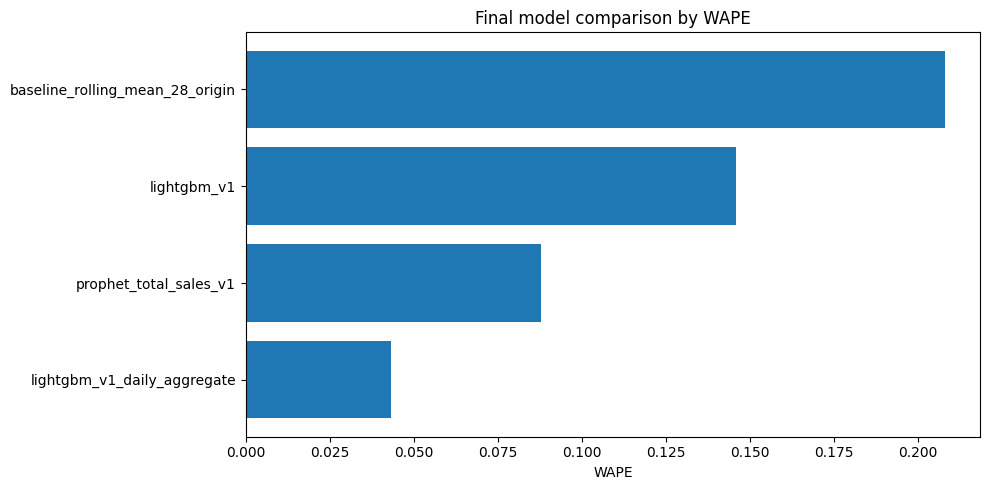

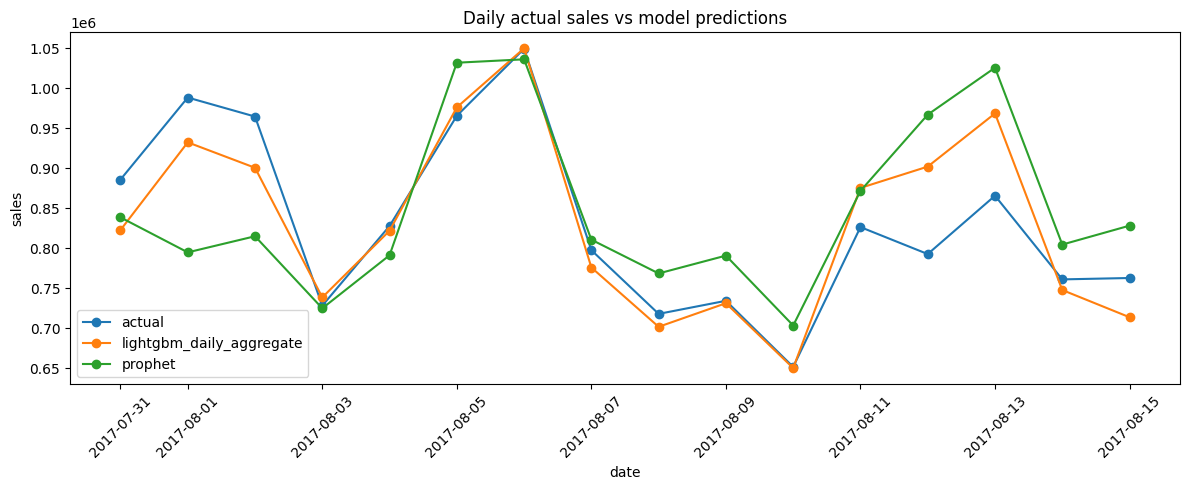

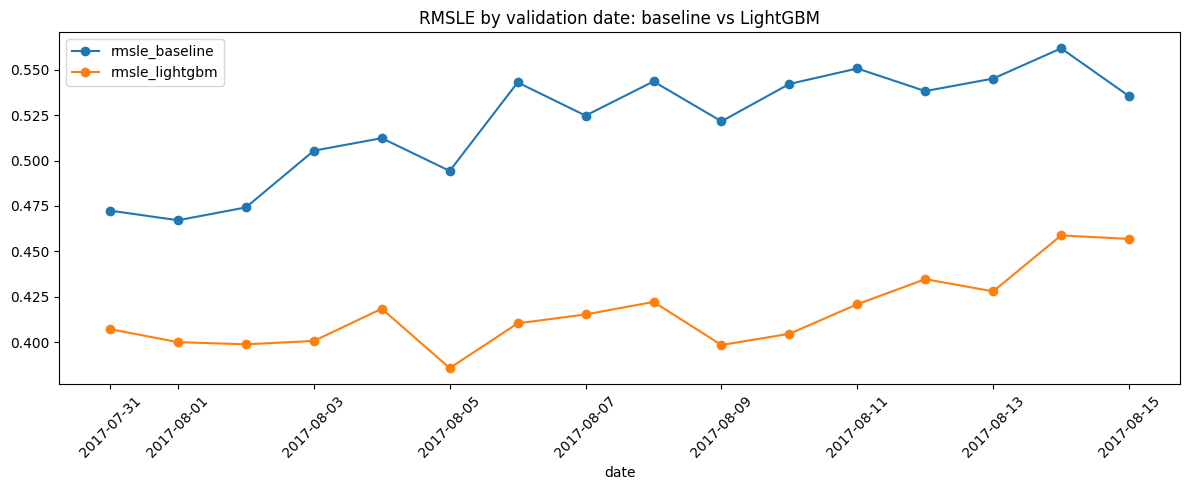

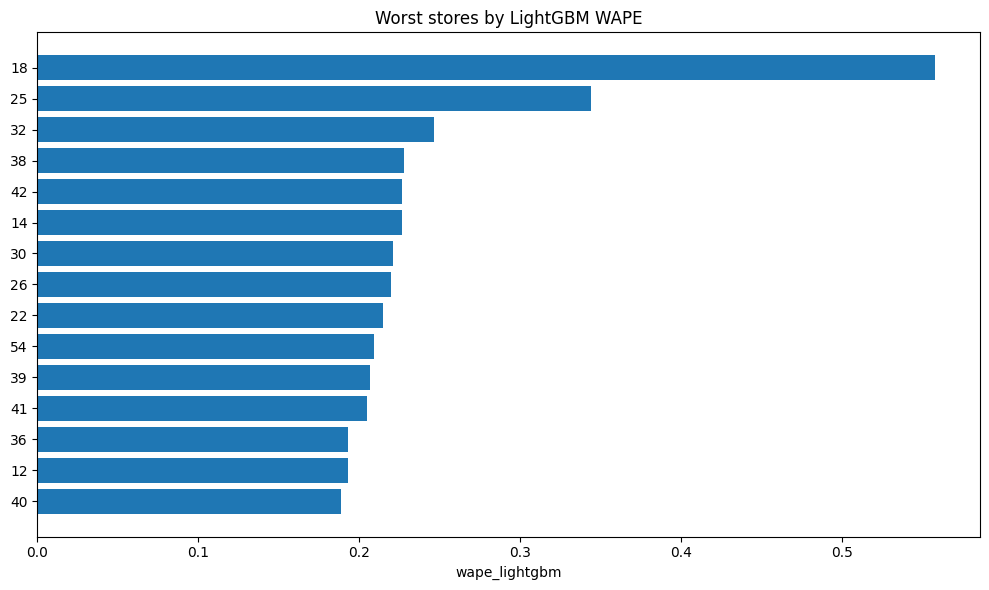

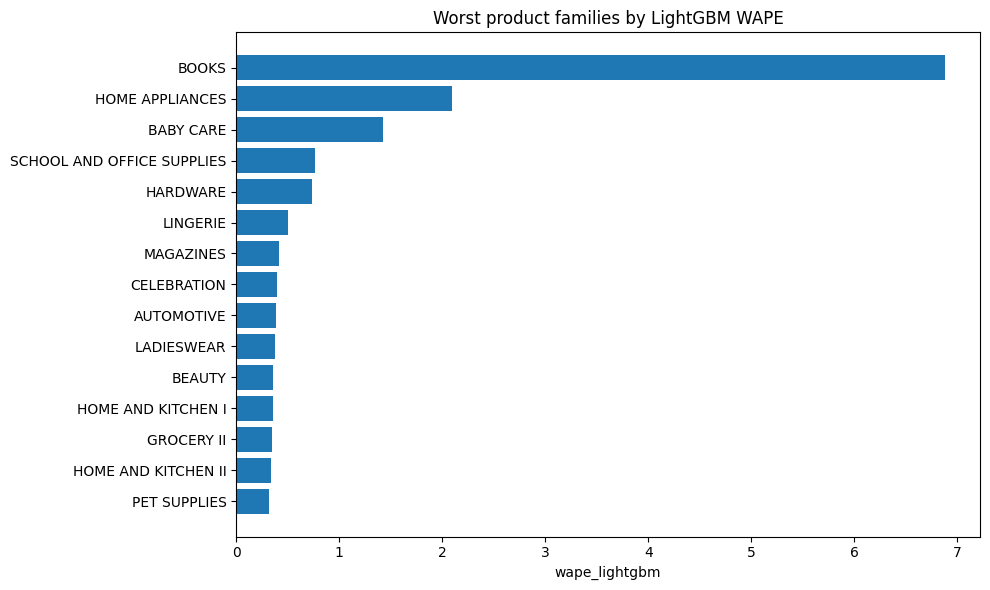

In [27]:
GLOBAL_METRICS_FIGURE_PATH = (
    REPORTS_FIGURES_DIR / "final_model_global_metrics_comparison.png"
)
DAILY_ACTUAL_VS_PREDICTION_FIGURE_PATH = (
    REPORTS_FIGURES_DIR / "final_daily_actual_vs_prediction.png"
)
ERROR_BY_DATE_FIGURE_PATH = REPORTS_FIGURES_DIR / "final_error_by_date.png"
WORST_STORES_FIGURE_PATH = REPORTS_FIGURES_DIR / "final_worst_stores_by_wape.png"
WORST_FAMILIES_FIGURE_PATH = REPORTS_FIGURES_DIR / "final_worst_families_by_wape.png"

# Global WAPE comparison
plot_df = final_model_leaderboard.copy().sort_values("wape", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model"].astype(str), plot_df["wape"])
plt.title("Final model comparison by WAPE")
plt.xlabel("WAPE")
plt.tight_layout()
plt.savefig(GLOBAL_METRICS_FIGURE_PATH, dpi=120, bbox_inches="tight")
plt.show()

# Daily actual vs predictions
daily_plot_df = daily_prediction_comparison.copy().sort_values("ds")

plt.figure(figsize=(12, 5))
plt.plot(daily_plot_df["ds"], daily_plot_df["actual"], marker="o", label="actual")
plt.plot(
    daily_plot_df["ds"],
    daily_plot_df["lightgbm_prediction"],
    marker="o",
    label="lightgbm_daily_aggregate",
)
plt.plot(
    daily_plot_df["ds"],
    daily_plot_df["prophet_prediction"],
    marker="o",
    label="prophet",
)
plt.title("Daily actual sales vs model predictions")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DAILY_ACTUAL_VS_PREDICTION_FIGURE_PATH, dpi=120, bbox_inches="tight")
plt.show()

# Error by date
plot_line(
    df=final_error_by_date.sort_values("date"),
    x_col="date",
    y_cols=["rmsle_baseline", "rmsle_lightgbm"],
    title="RMSLE by validation date: baseline vs LightGBM",
    output_path=ERROR_BY_DATE_FIGURE_PATH,
)

# Worst stores and families
plot_barh(
    df=worst_stores_by_wape,
    label_col="store_nbr",
    value_col="wape_lightgbm",
    title="Worst stores by LightGBM WAPE",
    output_path=WORST_STORES_FIGURE_PATH,
    n_rows=15,
)

plot_barh(
    df=worst_families_by_wape,
    label_col="family",
    value_col="wape_lightgbm",
    title="Worst product families by LightGBM WAPE",
    output_path=WORST_FAMILIES_FIGURE_PATH,
    n_rows=15,
)


## Business interpretation and decision matrix

This section translates model evaluation results into a business-oriented decision.

The decision considers:

- technical accuracy;
- operational granularity;
- forecast bias;
- segment robustness;
- interpretability;
- deployment readiness;
- suitability for store replenishment.

### Section conclusion

The final model should be selected based on business usefulness and technical evidence, not only on a single metric.


In [ ]:
lightgbm_granular_rmsle = lightgbm_row["rmsle"]
baseline_granular_rmsle = best_baseline_row["rmsle"]

lightgbm_granular_wape = lightgbm_row["wape"]
baseline_granular_wape = best_baseline_row["wape"]

lightgbm_granular_total_bias_pct = lightgbm_row["total_bias_pct"]

lightgbm_daily_row = daily_aggregate_model_comparison.query(
    "model == @LIGHTGBM_MODEL_VERSION + '_daily_aggregate'"
)

if lightgbm_daily_row.empty:
    lightgbm_daily_row = daily_aggregate_model_comparison.query(
        "model == @LIGHTGBM_MODEL_VERSION + '_daily_aggregate'"
    )

prophet_daily_row = daily_aggregate_model_comparison.query(
    "model == @PROPHET_MODEL_VERSION"
)

lightgbm_daily_rmsle = daily_aggregate_model_comparison.loc[
    daily_aggregate_model_comparison["model"]
    == f"{LIGHTGBM_MODEL_VERSION}_daily_aggregate",
    "rmsle",
].iloc[0]

prophet_daily_rmsle = daily_aggregate_model_comparison.loc[
    daily_aggregate_model_comparison["model"] == PROPHET_MODEL_VERSION,
    "rmsle",
].iloc[0]

lightgbm_wins_granular_rmsle = lightgbm_granular_rmsle < baseline_granular_rmsle
lightgbm_wins_granular_wape = lightgbm_granular_wape < baseline_granular_wape
lightgbm_bias_is_low = abs(lightgbm_granular_total_bias_pct) <= 0.05
lightgbm_wins_daily_rmsle = lightgbm_daily_rmsle < prophet_daily_rmsle

decision_matrix = pd.DataFrame(
    [
        {
            "criterion": "Operational granularity",
            "preferred_model": LIGHTGBM_MODEL_VERSION,
            "evidence": "Predicts at date + store_nbr + family level.",
            "decision_impact": "critical",
            "status": "passed",
        },
        {
            "criterion": "Granular RMSLE vs best baseline",
            "preferred_model": (
                LIGHTGBM_MODEL_VERSION
                if lightgbm_wins_granular_rmsle
                else BEST_BASELINE_MODEL
            ),
            "evidence": (
                f"LightGBM RMSLE: {lightgbm_granular_rmsle:.4f}; "
                f"best baseline RMSLE: {baseline_granular_rmsle:.4f}"
            ),
            "decision_impact": "critical",
            "status": "passed" if lightgbm_wins_granular_rmsle else "review",
        },
        {
            "criterion": "Granular WAPE vs best baseline",
            "preferred_model": (
                LIGHTGBM_MODEL_VERSION
                if lightgbm_wins_granular_wape
                else BEST_BASELINE_MODEL
            ),
            "evidence": (
                f"LightGBM WAPE: {lightgbm_granular_wape:.4f}; "
                f"best baseline WAPE: {baseline_granular_wape:.4f}"
            ),
            "decision_impact": "high",
            "status": "passed" if lightgbm_wins_granular_wape else "review",
        },
        {
            "criterion": "Total forecast bias",
            "preferred_model": LIGHTGBM_MODEL_VERSION,
            "evidence": (
                f"LightGBM total bias pct: " f"{lightgbm_granular_total_bias_pct:.4f}"
            ),
            "decision_impact": "high",
            "status": "passed" if lightgbm_bias_is_low else "review",
        },
        {
            "criterion": "Daily aggregate comparison vs Prophet",
            "preferred_model": (
                LIGHTGBM_MODEL_VERSION
                if lightgbm_wins_daily_rmsle
                else PROPHET_MODEL_VERSION
            ),
            "evidence": (
                f"LightGBM daily RMSLE: {lightgbm_daily_rmsle:.4f}; "
                f"Prophet daily RMSLE: {prophet_daily_rmsle:.4f}"
            ),
            "decision_impact": "medium",
            "status": "passed" if lightgbm_wins_daily_rmsle else "review",
        },
        {
            "criterion": "Deployment readiness",
            "preferred_model": LIGHTGBM_MODEL_VERSION,
            "evidence": "Serialized model, feature list, config, validation predictions and submission artifacts already exist.",
            "decision_impact": "high",
            "status": "passed",
        },
        {
            "criterion": "Interpretability benchmark",
            "preferred_model": PROPHET_MODEL_VERSION,
            "evidence": "Prophet provides useful aggregate trend, weekly seasonality, yearly seasonality and holiday components.",
            "decision_impact": "supporting",
            "status": "supporting_model",
        },
    ]
)

display(decision_matrix)


,criterion,preferred_model,evidence,decision_impact,status
0,Operational granularity,lightgbm_v1,Predicts at date + store_nbr + family level.,critical,passed
1,Granular RMSLE vs best baseline,lightgbm_v1,LightGBM RMSLE: 0.4167; best baseline RMSLE: 0...,critical,passed
2,Granular WAPE vs best baseline,lightgbm_v1,LightGBM WAPE: 0.1459; best baseline WAPE: 0.2081,high,passed
3,Total forecast bias,lightgbm_v1,LightGBM total bias pct: -0.0008,high,passed
4,Daily aggregate comparison vs Prophet,lightgbm_v1,LightGBM daily RMSLE: 0.0574; Prophet daily RM...,medium,passed
5,Deployment readiness,lightgbm_v1,"Serialized model, feature list, config, valida...",high,passed
6,Interpretability benchmark,prophet_total_sales_v1,"Prophet provides useful aggregate trend, weekl...",supporting,supporting_model


# 17.Final model recommendation

This section defines the final model recommended for the project.

The recommendation is based on:

- fair comparison by granularity;
- granular validation performance;
- business usefulness for replenishment;
- aggregate comparison against Prophet;
- bias control;
- MLOps readiness.

### Section conclusion

The final model should be the one that best supports the operational forecasting use case and can move cleanly into the next MLOps phase.


In [29]:
critical_checks_passed = (
    lightgbm_wins_granular_rmsle
    and lightgbm_wins_granular_wape
    and lightgbm_bias_is_low
)

if critical_checks_passed:
    recommended_model = LIGHTGBM_MODEL_VERSION
    recommendation_status = "recommended_for_next_mlops_phase"
    recommendation_reason = (
        "LightGBM is recommended because it improves the best granular baseline, "
        "keeps total forecast bias controlled, supports the required store-family-date "
        "forecasting grain, and is ready to be versioned and served."
    )
else:
    recommended_model = LIGHTGBM_MODEL_VERSION
    recommendation_status = "recommended_with_monitoring_notes"
    recommendation_reason = (
        "LightGBM remains the recommended operational model because it is the only "
        "advanced model available at store-family-date level. However, at least one "
        "critical metric should be reviewed before deployment."
    )

final_model_recommendation = pd.DataFrame(
    [
        {
            "recommended_model": recommended_model,
            "model_version": LIGHTGBM_MODEL_VERSION,
            "recommendation_status": recommendation_status,
            "recommended_use": "store_family_daily_sales_forecasting",
            "business_use_case": "short_term_store_replenishment_and_demand_planning",
            "validation_grain": "date_store_family",
            "forecast_horizon_days": EXPECTED_FORECAST_HORIZON_DAYS,
            "rmsle": lightgbm_granular_rmsle,
            "mae": lightgbm_row["mae"],
            "wape": lightgbm_granular_wape,
            "total_bias_pct": lightgbm_granular_total_bias_pct,
            "best_baseline": BEST_BASELINE_MODEL,
            "best_baseline_rmsle": baseline_granular_rmsle,
            "best_baseline_wape": baseline_granular_wape,
            "prophet_role": "aggregate_interpretable_benchmark",
            "recommendation_reason": recommendation_reason,
            "main_business_strength": (
                "Produces forecasts at the level required for store and product-family replenishment."
            ),
            "main_business_risk": (
                "Some stores, families, promotion periods or holiday/event dates may still need monitoring."
            ),
            "next_step": "register_lightgbm_v1_in_mlflow_then_prepare_fastapi_contract",
        }
    ]
)

display(final_model_recommendation)


,recommended_model,model_version,recommendation_status,recommended_use,business_use_case,validation_grain,forecast_horizon_days,rmsle,mae,wape,total_bias_pct,best_baseline,best_baseline_rmsle,best_baseline_wape,prophet_role,recommendation_reason,main_business_strength,main_business_risk,next_step
0,lightgbm_v1,lightgbm_v1,recommended_for_next_mlops_phase,store_family_daily_sales_forecasting,short_term_store_replenishment_and_demand_plan...,date_store_family,16,0.4167,68.1379,0.1459,-0.0008,baseline_rolling_mean_28_origin,0.5216,0.2081,aggregate_interpretable_benchmark,LightGBM is recommended because it improves th...,Produces forecasts at the level required for s...,"Some stores, families, promotion periods or ho...",register_lightgbm_v1_in_mlflow_then_prepare_fa...


### Final decision

The recommended final model for the project is:

`lightgbm_v1`

LightGBM is selected as the main operational forecasting model because it predicts at the required `date + store_nbr + family` grain and can support store replenishment decisions.

Prophet remains useful as an aggregate benchmark and interpretability tool, but it is not selected as the final operational model because it does not produce store-family level forecasts.

The best baseline remains useful as the minimum benchmark that future models should beat.

### Business conclusion

For the business objective of planning store replenishment over a 16-day horizon, LightGBM provides the best balance between accuracy, granularity, bias control and deployment readiness.


# 18.MLflow readiness

This section lists the metrics, parameters, tags and artifacts that should be registered later in MLflow.

MLflow is not implemented in this notebook. This section only prepares the tracking plan for the next phase.

### Section conclusion

The project is ready to move from notebook-based evaluation to experiment tracking and model registry structure.


In [ ]:
mlflow_metrics_recommendation = pd.DataFrame(
    [
        {
            "category": "metric",
            "name": "valid_rmsle",
            "value_source": "lightgbm_v1_metrics.csv",
        },
        {
            "category": "metric",
            "name": "valid_mae",
            "value_source": "lightgbm_v1_metrics.csv",
        },
        {
            "category": "metric",
            "name": "valid_wape",
            "value_source": "lightgbm_v1_metrics.csv",
        },
        {
            "category": "metric",
            "name": "valid_bias",
            "value_source": "lightgbm_v1_metrics.csv",
        },
        {
            "category": "metric",
            "name": "valid_total_bias_pct",
            "value_source": "lightgbm_v1_metrics.csv",
        },
        {
            "category": "metric",
            "name": "train_rmse_log",
            "value_source": "lightgbm_v1_training_summary.csv",
        },
        {
            "category": "metric",
            "name": "valid_rmse_log",
            "value_source": "lightgbm_v1_training_summary.csv",
        },
        {
            "category": "metric",
            "name": "rmse_log_gap",
            "value_source": "lightgbm_v1_overfitting_summary.csv",
        },
        {
            "category": "metric",
            "name": "best_iteration",
            "value_source": "lightgbm_v1_config.json",
        },
    ]
)

mlflow_tags_recommendation = pd.DataFrame(
    [
        {"category": "tag", "name": "project", "value": "store_sales_forecasting"},
        {"category": "tag", "name": "model_family", "value": "lightgbm"},
        {"category": "tag", "name": "model_version", "value": LIGHTGBM_MODEL_VERSION},
        {"category": "tag", "name": "target", "value": "log1p_sales"},
        {
            "category": "tag",
            "name": "forecast_horizon_days",
            "value": EXPECTED_FORECAST_HORIZON_DAYS,
        },
        {"category": "tag", "name": "granularity", "value": "date_store_family"},
        {
            "category": "tag",
            "name": "validation_strategy",
            "value": "temporal_holdout_16_days",
        },
        {"category": "tag", "name": "recommended_for_deployment", "value": "true"},
    ]
)

mlflow_artifacts_recommendation = pd.DataFrame(
    [
        {
            "artifact_type": "model",
            "path": LIGHTGBM_MODEL_PATH,
            "register": LIGHTGBM_MODEL_PATH.exists(),
        },
        {
            "artifact_type": "config",
            "path": LIGHTGBM_CONFIG_PATH,
            "register": LIGHTGBM_CONFIG_PATH.exists(),
        },
        {
            "artifact_type": "feature_list",
            "path": LIGHTGBM_FEATURE_LIST_PATH,
            "register": LIGHTGBM_FEATURE_LIST_PATH.exists(),
        },
        {
            "artifact_type": "validation_predictions",
            "path": LIGHTGBM_VALIDATION_PREDICTIONS_PATH,
            "register": LIGHTGBM_VALIDATION_PREDICTIONS_PATH.exists(),
        },
        {
            "artifact_type": "test_predictions",
            "path": LIGHTGBM_TEST_PREDICTIONS_PATH,
            "register": LIGHTGBM_TEST_PREDICTIONS_PATH.exists(),
        },
        {
            "artifact_type": "submission",
            "path": LIGHTGBM_SUBMISSION_PATH,
            "register": LIGHTGBM_SUBMISSION_PATH.exists(),
        },
        {
            "artifact_type": "final_leaderboard",
            "path": FINAL_MODEL_LEADERBOARD_PATH,
            "register": True,
        },
        {
            "artifact_type": "final_decision_matrix",
            "path": FINAL_DECISION_MATRIX_PATH,
            "register": True,
        },
        {
            "artifact_type": "final_recommendation",
            "path": FINAL_MODEL_RECOMMENDATION_PATH,
            "register": True,
        },
        {
            "artifact_type": "error_by_date",
            "path": FINAL_ERROR_BY_DATE_PATH,
            "register": True,
        },
        {
            "artifact_type": "error_by_store",
            "path": FINAL_ERROR_BY_STORE_PATH,
            "register": True,
        },
        {
            "artifact_type": "error_by_family",
            "path": FINAL_ERROR_BY_FAMILY_PATH,
            "register": True,
        },
        {
            "artifact_type": "figure_global_metrics",
            "path": GLOBAL_METRICS_FIGURE_PATH,
            "register": GLOBAL_METRICS_FIGURE_PATH.exists(),
        },
        {
            "artifact_type": "figure_daily_comparison",
            "path": DAILY_ACTUAL_VS_PREDICTION_FIGURE_PATH,
            "register": DAILY_ACTUAL_VS_PREDICTION_FIGURE_PATH.exists(),
        },
        {
            "artifact_type": "figure_error_by_date",
            "path": ERROR_BY_DATE_FIGURE_PATH,
            "register": ERROR_BY_DATE_FIGURE_PATH.exists(),
        },
    ]
)

mlflow_readiness_summary = pd.concat(
    [
        mlflow_metrics_recommendation,
        mlflow_tags_recommendation.rename(columns={"value": "value_source"}),
    ],
    ignore_index=True,
)

display(mlflow_metrics_recommendation)
display(mlflow_tags_recommendation)
display(mlflow_artifacts_recommendation)


,category,name,value_source
0,metric,valid_rmsle,lightgbm_v1_metrics.csv
1,metric,valid_mae,lightgbm_v1_metrics.csv
2,metric,valid_wape,lightgbm_v1_metrics.csv
3,metric,valid_bias,lightgbm_v1_metrics.csv
4,metric,valid_total_bias_pct,lightgbm_v1_metrics.csv
5,metric,train_rmse_log,lightgbm_v1_training_summary.csv
6,metric,valid_rmse_log,lightgbm_v1_training_summary.csv
7,metric,rmse_log_gap,lightgbm_v1_overfitting_summary.csv
8,metric,best_iteration,lightgbm_v1_config.json


,category,name,value
0,tag,project,store_sales_forecasting
1,tag,model_family,lightgbm
2,tag,model_version,lightgbm_v1
3,tag,target,log1p_sales
4,tag,forecast_horizon_days,16
5,tag,granularity,date_store_family
6,tag,validation_strategy,temporal_holdout_16_days
7,tag,recommended_for_deployment,true


,artifact_type,path,register
0,model,....,True
1,config,....,True
2,feature_list,....,True
3,validation_predictions,....,True
4,test_predictions,....,True
5,submission,....,True
6,final_leaderboard,....,True
7,final_decision_matrix,....,True
8,final_recommendation,....,True
9,error_by_date,....,True


# 19.Save final evaluation outputs

This section saves the final comparison tables, decision matrix, recommendation, error analysis outputs and MLflow tracking plan.

These artifacts will be useful for:

- the final README;
- MLflow experiment tracking;
- model registry documentation;
- future deployment preparation;
- portfolio evidence.

### Section conclusion

The notebook produces reusable evaluation artifacts instead of leaving conclusions only inside notebook outputs.


In [ ]:
save_dataframe(final_model_leaderboard, FINAL_MODEL_LEADERBOARD_PATH)
save_dataframe(granular_model_comparison, FINAL_GRANULAR_COMPARISON_PATH)
save_dataframe(daily_aggregate_model_comparison, FINAL_DAILY_COMPARISON_PATH)
save_dataframe(decision_matrix, FINAL_DECISION_MATRIX_PATH)
save_dataframe(final_model_recommendation, FINAL_MODEL_RECOMMENDATION_PATH)

save_dataframe(final_error_by_date, FINAL_ERROR_BY_DATE_PATH)
save_dataframe(final_error_by_horizon, FINAL_ERROR_BY_HORIZON_PATH)
save_dataframe(final_error_by_store, FINAL_ERROR_BY_STORE_PATH)
save_dataframe(final_error_by_family, FINAL_ERROR_BY_FAMILY_PATH)
save_dataframe(final_error_by_promotion, FINAL_ERROR_BY_PROMOTION_PATH)
save_dataframe(final_error_by_holiday, FINAL_ERROR_BY_HOLIDAY_PATH)

save_dataframe(mlflow_artifacts_recommendation, MLFLOW_ARTIFACTS_RECOMMENDATION_PATH)

saved_final_outputs = pd.DataFrame(
    [
        {"output": "final_model_leaderboard", "path": FINAL_MODEL_LEADERBOARD_PATH},
        {
            "output": "final_granular_model_comparison",
            "path": FINAL_GRANULAR_COMPARISON_PATH,
        },
        {
            "output": "final_daily_aggregate_model_comparison",
            "path": FINAL_DAILY_COMPARISON_PATH,
        },
        {"output": "final_model_decision_matrix", "path": FINAL_DECISION_MATRIX_PATH},
        {
            "output": "final_model_recommendation",
            "path": FINAL_MODEL_RECOMMENDATION_PATH,
        },
        {"output": "final_error_by_date", "path": FINAL_ERROR_BY_DATE_PATH},
        {"output": "final_error_by_horizon_day", "path": FINAL_ERROR_BY_HORIZON_PATH},
        {"output": "final_error_by_store", "path": FINAL_ERROR_BY_STORE_PATH},
        {"output": "final_error_by_family", "path": FINAL_ERROR_BY_FAMILY_PATH},
        {"output": "final_error_by_promotion", "path": FINAL_ERROR_BY_PROMOTION_PATH},
        {"output": "final_error_by_holiday", "path": FINAL_ERROR_BY_HOLIDAY_PATH},
        {
            "output": "mlflow_artifacts_recommendation",
            "path": MLFLOW_ARTIFACTS_RECOMMENDATION_PATH,
        },
        {
            "output": "final_model_global_metrics_comparison_figure",
            "path": GLOBAL_METRICS_FIGURE_PATH,
        },
        {
            "output": "final_daily_actual_vs_prediction_figure",
            "path": DAILY_ACTUAL_VS_PREDICTION_FIGURE_PATH,
        },
        {"output": "final_error_by_date_figure", "path": ERROR_BY_DATE_FIGURE_PATH},
        {
            "output": "final_worst_stores_by_wape_figure",
            "path": WORST_STORES_FIGURE_PATH,
        },
        {
            "output": "final_worst_families_by_wape_figure",
            "path": WORST_FAMILIES_FIGURE_PATH,
        },
    ]
)

saved_final_outputs["exists"] = saved_final_outputs["path"].apply(
    lambda path: Path(path).exists()
)
saved_final_outputs["file_size_mb"] = saved_final_outputs["path"].apply(file_size_mb)
saved_final_outputs["relative_path"] = saved_final_outputs["path"].apply(
    lambda path: (
        Path(path).relative_to(PROJECT_ROOT) if Path(path).exists() else str(path)
    )
)

display(saved_final_outputs)

missing_final_outputs = saved_final_outputs.query("exists == False")

if not missing_final_outputs.empty:
    raise FileNotFoundError(
        "Some final evaluation outputs were not saved correctly:\n"
        + "\n".join(
            [
                f"- {row.output}: {row.path}"
                for row in missing_final_outputs.itertuples(index=False)
            ]
        )
    )

print("Final evaluation outputs saved successfully.")


,output,path,exists,file_size_mb,relative_path
0,final_model_leaderboard,....,True,0.0012,reports\tables\final_model_leaderboard.csv
1,final_granular_model_comparison,....,True,0.0008,reports\tables\final_granular_model_comparison...
2,final_daily_aggregate_model_comparison,....,True,0.0006,reports\tables\final_daily_aggregate_model_com...
3,final_model_decision_matrix,....,True,0.0009,reports\tables\final_model_decision_matrix.csv
4,final_model_recommendation,....,True,0.0010,reports\tables\final_model_recommendation.csv
5,final_error_by_date,....,True,0.0069,reports\tables\final_error_by_date.csv
6,final_error_by_horizon_day,....,True,0.0066,reports\tables\final_error_by_horizon_day.csv
7,final_error_by_store,....,True,0.0239,reports\tables\final_error_by_store.csv
8,final_error_by_family,....,True,0.0152,reports\tables\final_error_by_family.csv
9,final_error_by_promotion,....,True,0.0013,reports\tables\final_error_by_promotion.csv


Final evaluation outputs saved successfully.


# 20.Notebook closure criteria

This section validates whether the evaluation notebook can be considered complete.

The notebook is complete only if it has:

- loaded all required model artifacts;
- validated compatible comparison periods;
- respected model granularity;
- compared granular models fairly;
- compared Prophet only at daily aggregate level;
- analyzed errors by relevant business segments;
- saved final outputs;
- selected a final model;
- defined MLflow readiness artifacts.

### Section conclusion

The notebook should end with a clear model decision and reusable outputs for the next MLOps phase.


In [32]:
closure_criteria = pd.DataFrame(
    [
        {
            "criterion": "Required artifacts loaded",
            "status": "completed",
            "evidence": "All required predictions, metrics and configs were loaded.",
        },
        {
            "criterion": "Validation period checked",
            "status": "completed",
            "evidence": (
                f"Validation dates: "
                f"{lightgbm_validation_predictions['date'].min().date()} "
                f"to {lightgbm_validation_predictions['date'].max().date()}"
            ),
        },
        {
            "criterion": "Granularity respected",
            "status": "completed",
            "evidence": "Prophet was evaluated only at daily aggregate level.",
        },
        {
            "criterion": "Granular comparison created",
            "status": "completed",
            "evidence": "Baseline vs LightGBM comparison saved.",
        },
        {
            "criterion": "Daily aggregate comparison created",
            "status": "completed",
            "evidence": "LightGBM daily aggregate vs Prophet comparison saved.",
        },
        {
            "criterion": "Error by date analyzed",
            "status": "completed",
            "evidence": FINAL_ERROR_BY_DATE_PATH.name,
        },
        {
            "criterion": "Error by horizon analyzed",
            "status": "completed",
            "evidence": FINAL_ERROR_BY_HORIZON_PATH.name,
        },
        {
            "criterion": "Error by store analyzed",
            "status": "completed",
            "evidence": FINAL_ERROR_BY_STORE_PATH.name,
        },
        {
            "criterion": "Error by family analyzed",
            "status": "completed",
            "evidence": FINAL_ERROR_BY_FAMILY_PATH.name,
        },
        {
            "criterion": "Error by promotion analyzed",
            "status": "completed",
            "evidence": FINAL_ERROR_BY_PROMOTION_PATH.name,
        },
        {
            "criterion": "Error by holiday/event analyzed",
            "status": "completed",
            "evidence": FINAL_ERROR_BY_HOLIDAY_PATH.name,
        },
        {
            "criterion": "Final model selected",
            "status": "completed",
            "evidence": recommended_model,
        },
        {
            "criterion": "MLflow readiness documented",
            "status": "completed",
            "evidence": MLFLOW_ARTIFACTS_RECOMMENDATION_PATH.name,
        },
        {
            "criterion": "Final outputs saved",
            "status": "completed",
            "evidence": f"{len(saved_final_outputs)} outputs checked.",
        },
    ]
)

save_dataframe(closure_criteria, FINAL_NOTEBOOK_CLOSURE_PATH)

display(closure_criteria)

print("Notebook 06 completed successfully.")
print(f"Final recommended model: {recommended_model}")
print(f"Recommendation status: {recommendation_status}")
print(f"Next step: MLflow experiment tracking and model registry preparation.")


,criterion,status,evidence
0,Required artifacts loaded,completed,"All required predictions, metrics and configs ..."
1,Validation period checked,completed,Validation dates: 2017-07-31 to 2017-08-15
2,Granularity respected,completed,Prophet was evaluated only at daily aggregate ...
3,Granular comparison created,completed,Baseline vs LightGBM comparison saved.
4,Daily aggregate comparison created,completed,LightGBM daily aggregate vs Prophet comparison...
5,Error by date analyzed,completed,final_error_by_date.csv
6,Error by horizon analyzed,completed,final_error_by_horizon_day.csv
7,Error by store analyzed,completed,final_error_by_store.csv
8,Error by family analyzed,completed,final_error_by_family.csv
9,Error by promotion analyzed,completed,final_error_by_promotion.csv


Notebook 06 completed successfully.
Final recommended model: lightgbm_v1
Recommendation status: recommended_for_next_mlops_phase
Next step: MLflow experiment tracking and model registry preparation.


# Final conclusion

The final recommended model for the Corporación Favorita Store Sales Forecasting project is:

## `lightgbm_v1`

LightGBM is selected as the final operational model because it provides the best fit for the business problem:

- it predicts at the required `date + store_nbr + family` level;
- it improves the best baseline at the operational forecasting grain;
- it keeps aggregate bias under control;
- it supports the 16-day replenishment planning horizon;
- it has saved model, feature list, config, predictions and submission artifacts;
- it is ready to move into MLflow tracking and later FastAPI/Docker deployment.

Prophet is kept as a useful aggregate benchmark because it helps explain trend, weekly seasonality, yearly seasonality and holiday effects. However, it is not selected as the final model because it does not produce store-family level forecasts.

The best baseline remains important as the minimum benchmark that future models must beat.

## Business conclusion

For short-term store replenishment and demand planning, `lightgbm_v1` is the most appropriate model because it combines stronger predictive performance with the operational granularity required by the business.
